# **Unsupervised Learning Methods**
## **Clustering Patient Data: A Comparative Analysis**

**Authors:** Carla Bellido García, Cindy Chen, Celica Krigul, Keith Megara Osores Vicuña, Ema Štangová
  
**Master:** Health Data Science

**Subject:** Machine Learning

**Course:** 2025-2026

---

## **Table of Contents**

**1. [Overview](#section1)**   

**2. [Dataset](#section2)**  
&emsp; **2.1 [Heart Disease UCI Dataset](#section21)**     
&emsp; **2.1 [Features](#section22)**     
  
**3. [Assignment Tasks](#section3)**  
&emsp; **3.1 [Task 1 - Data Loading & Exploration](#section31)**   
&emsp; **3.2 [Task 2 - Preprocessing & Feature Engineering](#section32)**  
&emsp; **3.3 [Task 3 - Clustering: K-Means](#section33)**  
&emsp; **3.3 [Task 4 - Clustering: Gaussian Mixture Models](#section34)**  
&emsp; **3.3 [Task 5 - Clustering: Hierarchical Clustering](#section35)**  
&emsp; **3.3 [Task 6 - Clustering: Evaluation Against Ground Truth](#section36)**   

---
<a id='section1'></a>
## **Overview**

In this assignment, you will apply and compare three unsupervised learning methods - **K-Means Clustering, Gaussian Mixture Models (GMM), and Hierarchical Clustering** - to a real-world medical dataset. Your goal is to discover meaningful patient subgroups *without* using the diagnostic label, then evaluate how well your clusters align with the ground truth once it is revealed.

This mirrors a real challenge in health data science: identifying patient profiles from clinical measurements alone, before a diagnosis is available. The skills you practice here - preprocessing, dimensionality reduction,  clustering, and evaluation - form the backbone of many unsupervised pipelines in healthcare.

---
<a id='section2'></a>
## **Dataset**

<a id='section21'></a>
### **Heart Disease UCI Dataset**

You will work with the Heart Disease dataset from the UCI Machine Learning Repository, publicly available at: https://archive.ics.uci.edu/dataset/45/heart+disease 

The dataset (use only processed.cleveland.data) contains 303 patient records with 13 clinical features and one target variable. You must treat the target variable as hidden during clustering, and only use it for evaluation afterwards.

<a id='section22'></a>
### **Features**

|**Feature** |**Name**                |**Description**                                             |  
|------------|------------------------|------------------------------------------------------------|  
|``age``     |Age                     |Age in years                                                |  
|``sex``     |Sex                     |1 = male, 0 = female                                        |  
|``cp``      |Chest pain type         |4 types (0-3)                                               |  
|``trestbps``|Resting blood pressure  |mm Hg on admission                                          |  
|``chol``    |Serum cholesterol|mg/dl |mg/dl                                                       |  
|``fbs``     |Fasting blood sugar     | >120mg/dl: 1 = true, 0 = false                             |  
|``restecg`` |Resting ECG results     |Values 0, 1, 2                                              |  
|``thalach`` |Max heart rate achieved |Numeric                                                     |  
|``exang``   |Exercise-induced angina |1 = yes, 0 = no                                             |  
|``oldpeak`` |ST depression           |Induced by exercise vs. rest                                |  
|``slope``   |Slope of peak ST segment|Values 0, 1, 2                                              |  
|``ca``      |Major vessels (0-3)     |Coloured by fluoroscopy                                     |  
|``thal``    |Thal                    |3 = normal, 6 = fixed defect, 7 = reversible defect         |  
|``target``  |**Diagnosis (HIDDEN)**  |*0 = no disease, 1-4 = disease present. Binarise as 0 vs 1+*|  

---
<a id='section3'></a>
## **Assignment Tasks**

The assignment follows a single end-to-end pipeline. All team members should understand every stage, even if responsibilities are divided.

<a id='section31'></a>
### **Task 1 - Data Loading & Exploration**

In [1]:
# Libraries used
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.mixture import GaussianMixture
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.cluster.hierarchy import fcluster
from sklearn.metrics import adjusted_rand_score

- **Load the dataset and display its shape, data types, and summary statistics.**

In [2]:
# Load dataset
df = pd.read_csv("data/processed.cleveland.data", header=None)
print(df.head())

     0    1    2      3      4    5    6      7    8    9    10   11   12  13
0  63.0  1.0  1.0  145.0  233.0  1.0  2.0  150.0  0.0  2.3  3.0  0.0  6.0   0
1  67.0  1.0  4.0  160.0  286.0  0.0  2.0  108.0  1.0  1.5  2.0  3.0  3.0   2
2  67.0  1.0  4.0  120.0  229.0  0.0  2.0  129.0  1.0  2.6  2.0  2.0  7.0   1
3  37.0  1.0  3.0  130.0  250.0  0.0  0.0  187.0  0.0  3.5  3.0  0.0  3.0   0
4  41.0  0.0  2.0  130.0  204.0  0.0  2.0  172.0  0.0  1.4  1.0  0.0  3.0   0


In [3]:
# Add column names
cols = [
    "age",
    "sex",
    "cp",
    "trestbps",
    "chol",
    "fbs",
    "restecg",
    "thalach",
    "exang",
    "oldpeak",
    "slope",
    "ca",
    "thal",
    "target",
]

df.columns = cols
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


Column names were added and then, we used the ``head()`` function to preview the first rows of the dataset and understand what kind of data it contains. From this output we can see that the dataset has 14 columns, and most of the values are numerical. 

In [4]:
# Print shape
print(df.shape)

(303, 14)


We used the ``shape`` function to confirm the size of the dataset. The output shows that the dataset contains 303 rows and 14 columns.

In [5]:
# Print data types for each column
print(df.dtypes)

age         float64
sex         float64
cp          float64
trestbps    float64
chol        float64
fbs         float64
restecg     float64
thalach     float64
exang       float64
oldpeak     float64
slope       float64
ca           object
thal         object
target        int64
dtype: object


The ``dtypes`` function was then used to display the data types of each column, confirming the previously observed distribution of variable types. Columns 0–10 are of type float, columns 11–12 are object, and column 13 is an integer.

In [6]:
# Check for missing values
df.replace("?", pd.NA, inplace=True)
print(df.isnull().sum())

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
target      0
dtype: int64


Finally, we used ``isnull().sum()`` to count the number of missing values in each column. Before performing this check, the symbol "?" was replaced with NaN, since pandas does not interpret "?" as a missing value by default. Without this conversion, the dataset initially appeared to contain no missing values. After the replacement, the analysis revealed 4 missing values in the ``ca`` variable and 2 missing values in the ``thal`` variable, which will need to be handled during preprocessing.

In [7]:
# Convert to numeric
df["ca"] = pd.to_numeric(df["ca"])
df["thal"] = pd.to_numeric(df["thal"])

- **Identify and handle missing values. Document your strategy and justify it.**

We examined the values of both categorical and continuous variables to ensure that they fall within the expected and realistic ranges defined in the dataset documentation.

In [8]:
# Check unique values for categorical/binary variables
print("sex:", df["sex"].unique())
print("cp:", df["cp"].unique())
print("fbs:", df["fbs"].unique())
print("restecg:", df["restecg"].unique())
print("exang:", df["exang"].unique())
print("slope:", df["slope"].unique())
print("ca:", df["ca"].unique())
print("thal:", df["thal"].unique())
print("target:", df["target"].unique())

# Check basic ranges for continues variables
df[["age", "trestbps", "chol", "thalach", "oldpeak"]].describe()

sex: [1. 0.]
cp: [1. 4. 3. 2.]
fbs: [1. 0.]
restecg: [2. 0. 1.]
exang: [0. 1.]
slope: [3. 2. 1.]
ca: [ 0.  3.  2.  1. nan]
thal: [ 6.  3.  7. nan]
target: [0 2 1 3 4]


,age,trestbps,chol,thalach,oldpeak
count,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.438944,131.689769,246.693069,149.607261,1.039604
std,9.038662,17.599748,51.776918,22.875003,1.161075
min,29.000000,94.000000,126.000000,71.000000,0.000000
25%,48.000000,120.000000,211.000000,133.500000,0.000000
50%,56.000000,130.000000,241.000000,153.000000,0.800000
75%,61.000000,140.000000,275.000000,166.000000,1.600000
max,77.000000,200.000000,564.000000,202.000000,6.200000


The maximum resting blood pressure (``trestbps``) is 200 mmHg, which corresponds to a hypertensive crisis, indicating a critically high value. [heart.org](https://www.heart.org/en/health-topics/high-blood-pressure/understanding-blood-pressure-readings#:~:text=Use%20our%20blood%20pressure%20chart%20to%20learn,and%20the%20difference%20between%20systolic%20and%20diastolic.)

The variable ``chol`` (serum cholesterol) has a maximum value of 564 mg/dl, which is significantly higher than the recommended threshold. This indicates a case of severe hyperlipidemia. [clevelandclinic.org](https://my.clevelandclinic.org/health/diseases/21656-hyperlipidemia)

A common approximation for maximum heart rate is 220 − age. In our dataset, the youngest patient is 29 years old, giving an estimated maximum heart rate of 191 bpm. However, the dataset reports a maximum ``thalach`` value of 202 bpm, which exceeds this estimate even if it belonged to the youngest patient. This suggests a potential extreme observation. [heart.org](https://www.heart.org/en/healthy-living/fitness/fitness-basics/target-heart-rates#:~:text=Your%20maximum%20heart%20rate%20is,70%2D85%25%20of%20maximum.)

The variable ``oldpeak`` represents ST depression induced by exercise relative to rest. A value of 0.0 indicates no measurable ST depression, which is clinically possible. However, the maximum value 6.2 is unusually high and may represent an extreme observation, potentially related to severe ischemia during stress testing. [ecgwaves.com](https://ecgwaves.com/st-segment-normal-abnormal-depression-elevation-causes/?utm_source=chatgpt.com)

In [9]:
# Taking continuous (numeric) features to identify outliers
cols_continuous = ["age", "trestbps", "chol", "thalach", "oldpeak"]

outlier_list = []

for col in cols_continuous:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    mask = (df[col] < lower) | (df[col] > upper)

    for idx in df[mask].index:
        outlier_list.append({"column": col, "index": idx, "value": df.loc[idx, col]})

outliers_df = pd.DataFrame(outlier_list)

In [10]:
outliers_df

,column,index,value
0,trestbps,14,172.0
1,trestbps,83,180.0
2,trestbps,126,200.0
3,trestbps,172,174.0
4,trestbps,183,178.0
5,trestbps,188,192.0
6,trestbps,201,180.0
7,trestbps,213,178.0
8,trestbps,231,180.0
9,chol,48,417.0


The detected outliers using the IQR method correspond closely with clinically extreme values identified through domain knowledge. For example, very high resting blood pressure (up to 200 mmHg) and cholesterol levels (up to 564 mg/dl) are both statistically and medically significant, representing severe pathological conditions rather than data errors. However, not all clinically unusual values are captured by statistical methods. For instance, this method identifies unusually low heart rate values as outliers.
Since the subsequent analysis involves clustering methods such as K-means, Gaussian Mixture Models, and Hierarchical Clustering, the dataset will be scaled to ensure comparability between features. Rather than removing outliers, these extreme values will be retained, as they likely represent meaningful high-risk patient profiles. Their inclusion allows the clustering algorithms to capture clinically important subgroups within the data.

In [11]:
# Why and where the missing values happen?
df[df.isnull().any(axis=1)]

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
87,53.0,0.0,3.0,128.0,216.0,0.0,2.0,115.0,0.0,0.0,1.0,0.0,NaN,0
166,52.0,1.0,3.0,138.0,223.0,0.0,0.0,169.0,0.0,0.0,1.0,NaN,3.0,0
192,43.0,1.0,4.0,132.0,247.0,1.0,2.0,143.0,1.0,0.1,2.0,NaN,7.0,1
266,52.0,1.0,4.0,128.0,204.0,1.0,0.0,156.0,1.0,1.0,2.0,0.0,NaN,2
287,58.0,1.0,2.0,125.0,220.0,0.0,0.0,144.0,0.0,0.4,2.0,NaN,7.0,0
302,38.0,1.0,3.0,138.0,175.0,0.0,0.0,173.0,0.0,0.0,1.0,NaN,3.0,0


We observe that the missing values occur in different rows, which suggests that they may be missing because the diagnostic tests were not performed or the results were not recorded during data collection. Instead of removing these observations, we chose to apply imputation in order to preserve the dataset size. Since the variables contain discrete integer values, the median was selected as an appropriate method for filling the missing values.

In [12]:
# Median imputation
df["ca"] = df["ca"].fillna(df["ca"].median())
df["thal"] = df["thal"].fillna(df["thal"].median())

# Control
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

- **Plot distributions of all features (histograms, box plots).**

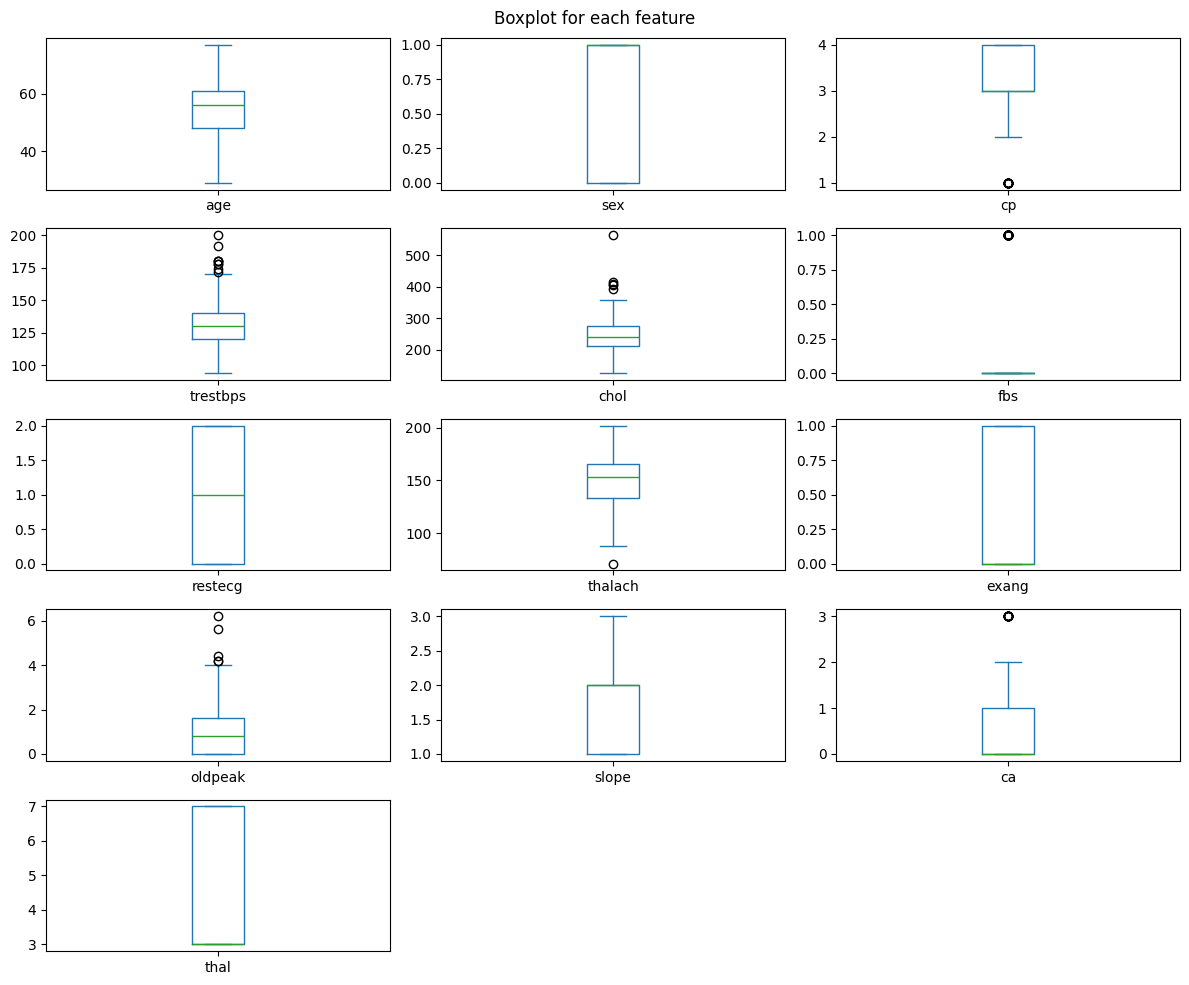

In [13]:
# Boxplots for all features
df.drop("target", axis=1).plot(
    kind="box",
    subplots=True,
    layout=(5, 3),
    sharex=False,
    sharey=False,
    figsize=(12, 10),
    title="Boxplot for each feature",
)

plt.tight_layout()
plt.savefig("figures/task1_feature_boxplot.png", dpi=150, bbox_inches="tight")
plt.show()

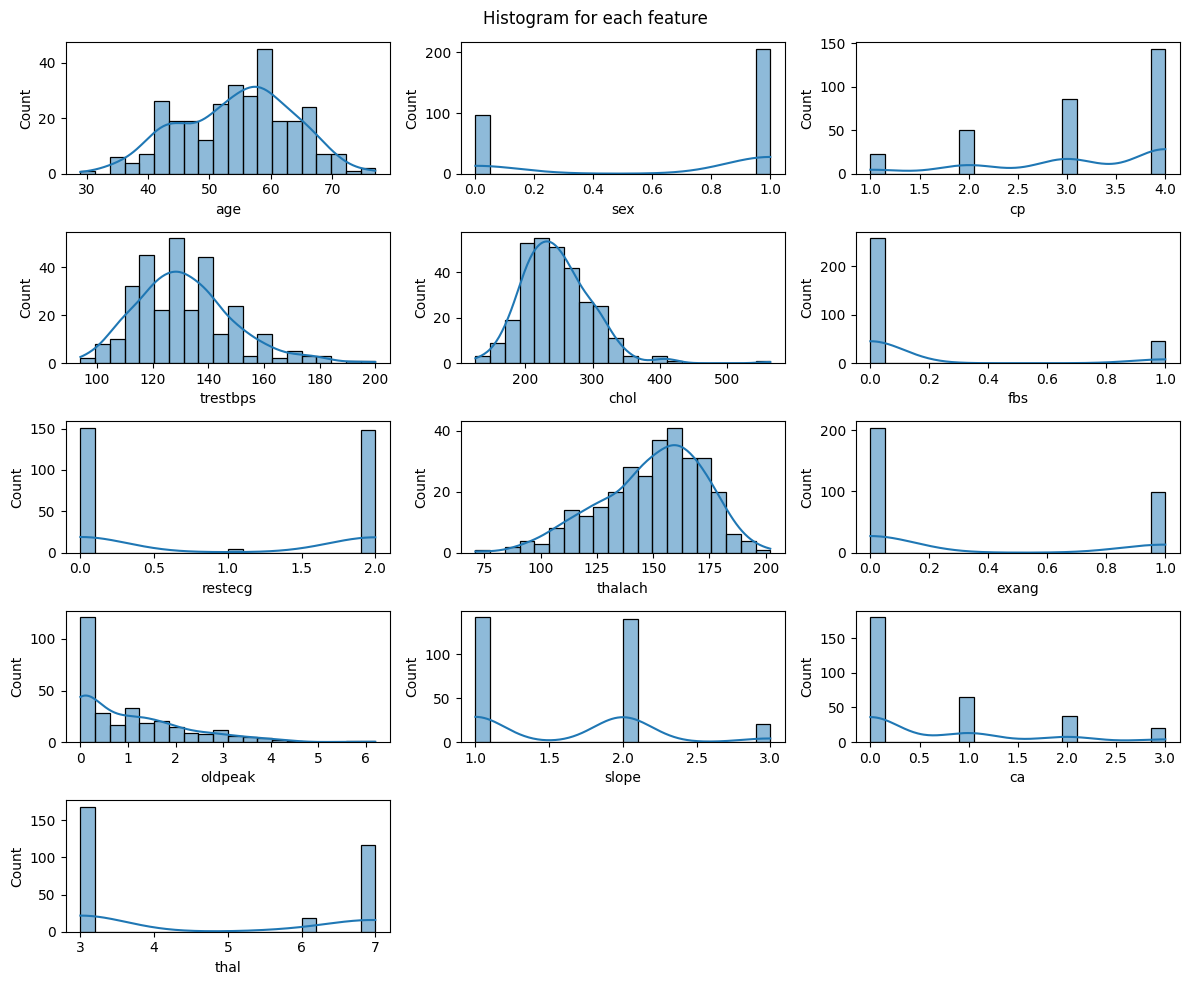

In [14]:
# Histograms for all features
features = df.drop("target", axis=1)

fig, axs = plt.subplots(5, 3, figsize=(12, 10))
axs = axs.ravel()

for i, col in enumerate(features.columns):
    sns.histplot(data=df, x=col, ax=axs[i], kde=True, bins=20)

for j in range(len(features.columns), len(axs)):
    fig.delaxes(axs[j])

plt.suptitle("Histogram for each feature")
plt.tight_layout()
plt.savefig("figures/task1_histogram.png", dpi=150, bbox_inches="tight")
plt.show()

<Axes: xlabel='oldpeak', ylabel='Count'>

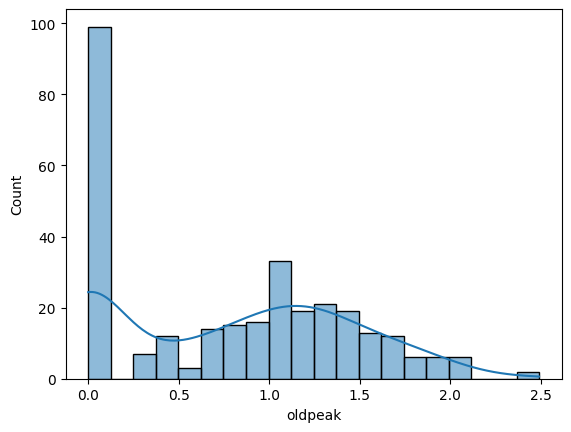

In [15]:
sns.histplot(x=np.sqrt(df["oldpeak"]), kde=True, bins=20)

Histograms and boxplots were used to analyze the distribution of all features and identify potential outliers. The continuous variables (``age``, ``trestbps``, ``chol``, ``thalach``, and ``oldpeak``) show wider distributions and several potential outliers, particularly in ``chol``, ``trestbps``, and ``oldpeak``.

In contrast, variables such as: ``sex``, ``fbs``, and ``exang`` are binary, while: ``cp``, ``restecg``, ``slope``, ``ca``, and ``thal`` are categorical, which results in discrete distributions. These observations are consistent with the expected structure of the dataset and help inform further preprocessing steps for machine learning.

- **Plot a correlation heatmap. Discuss which features appear most related.**

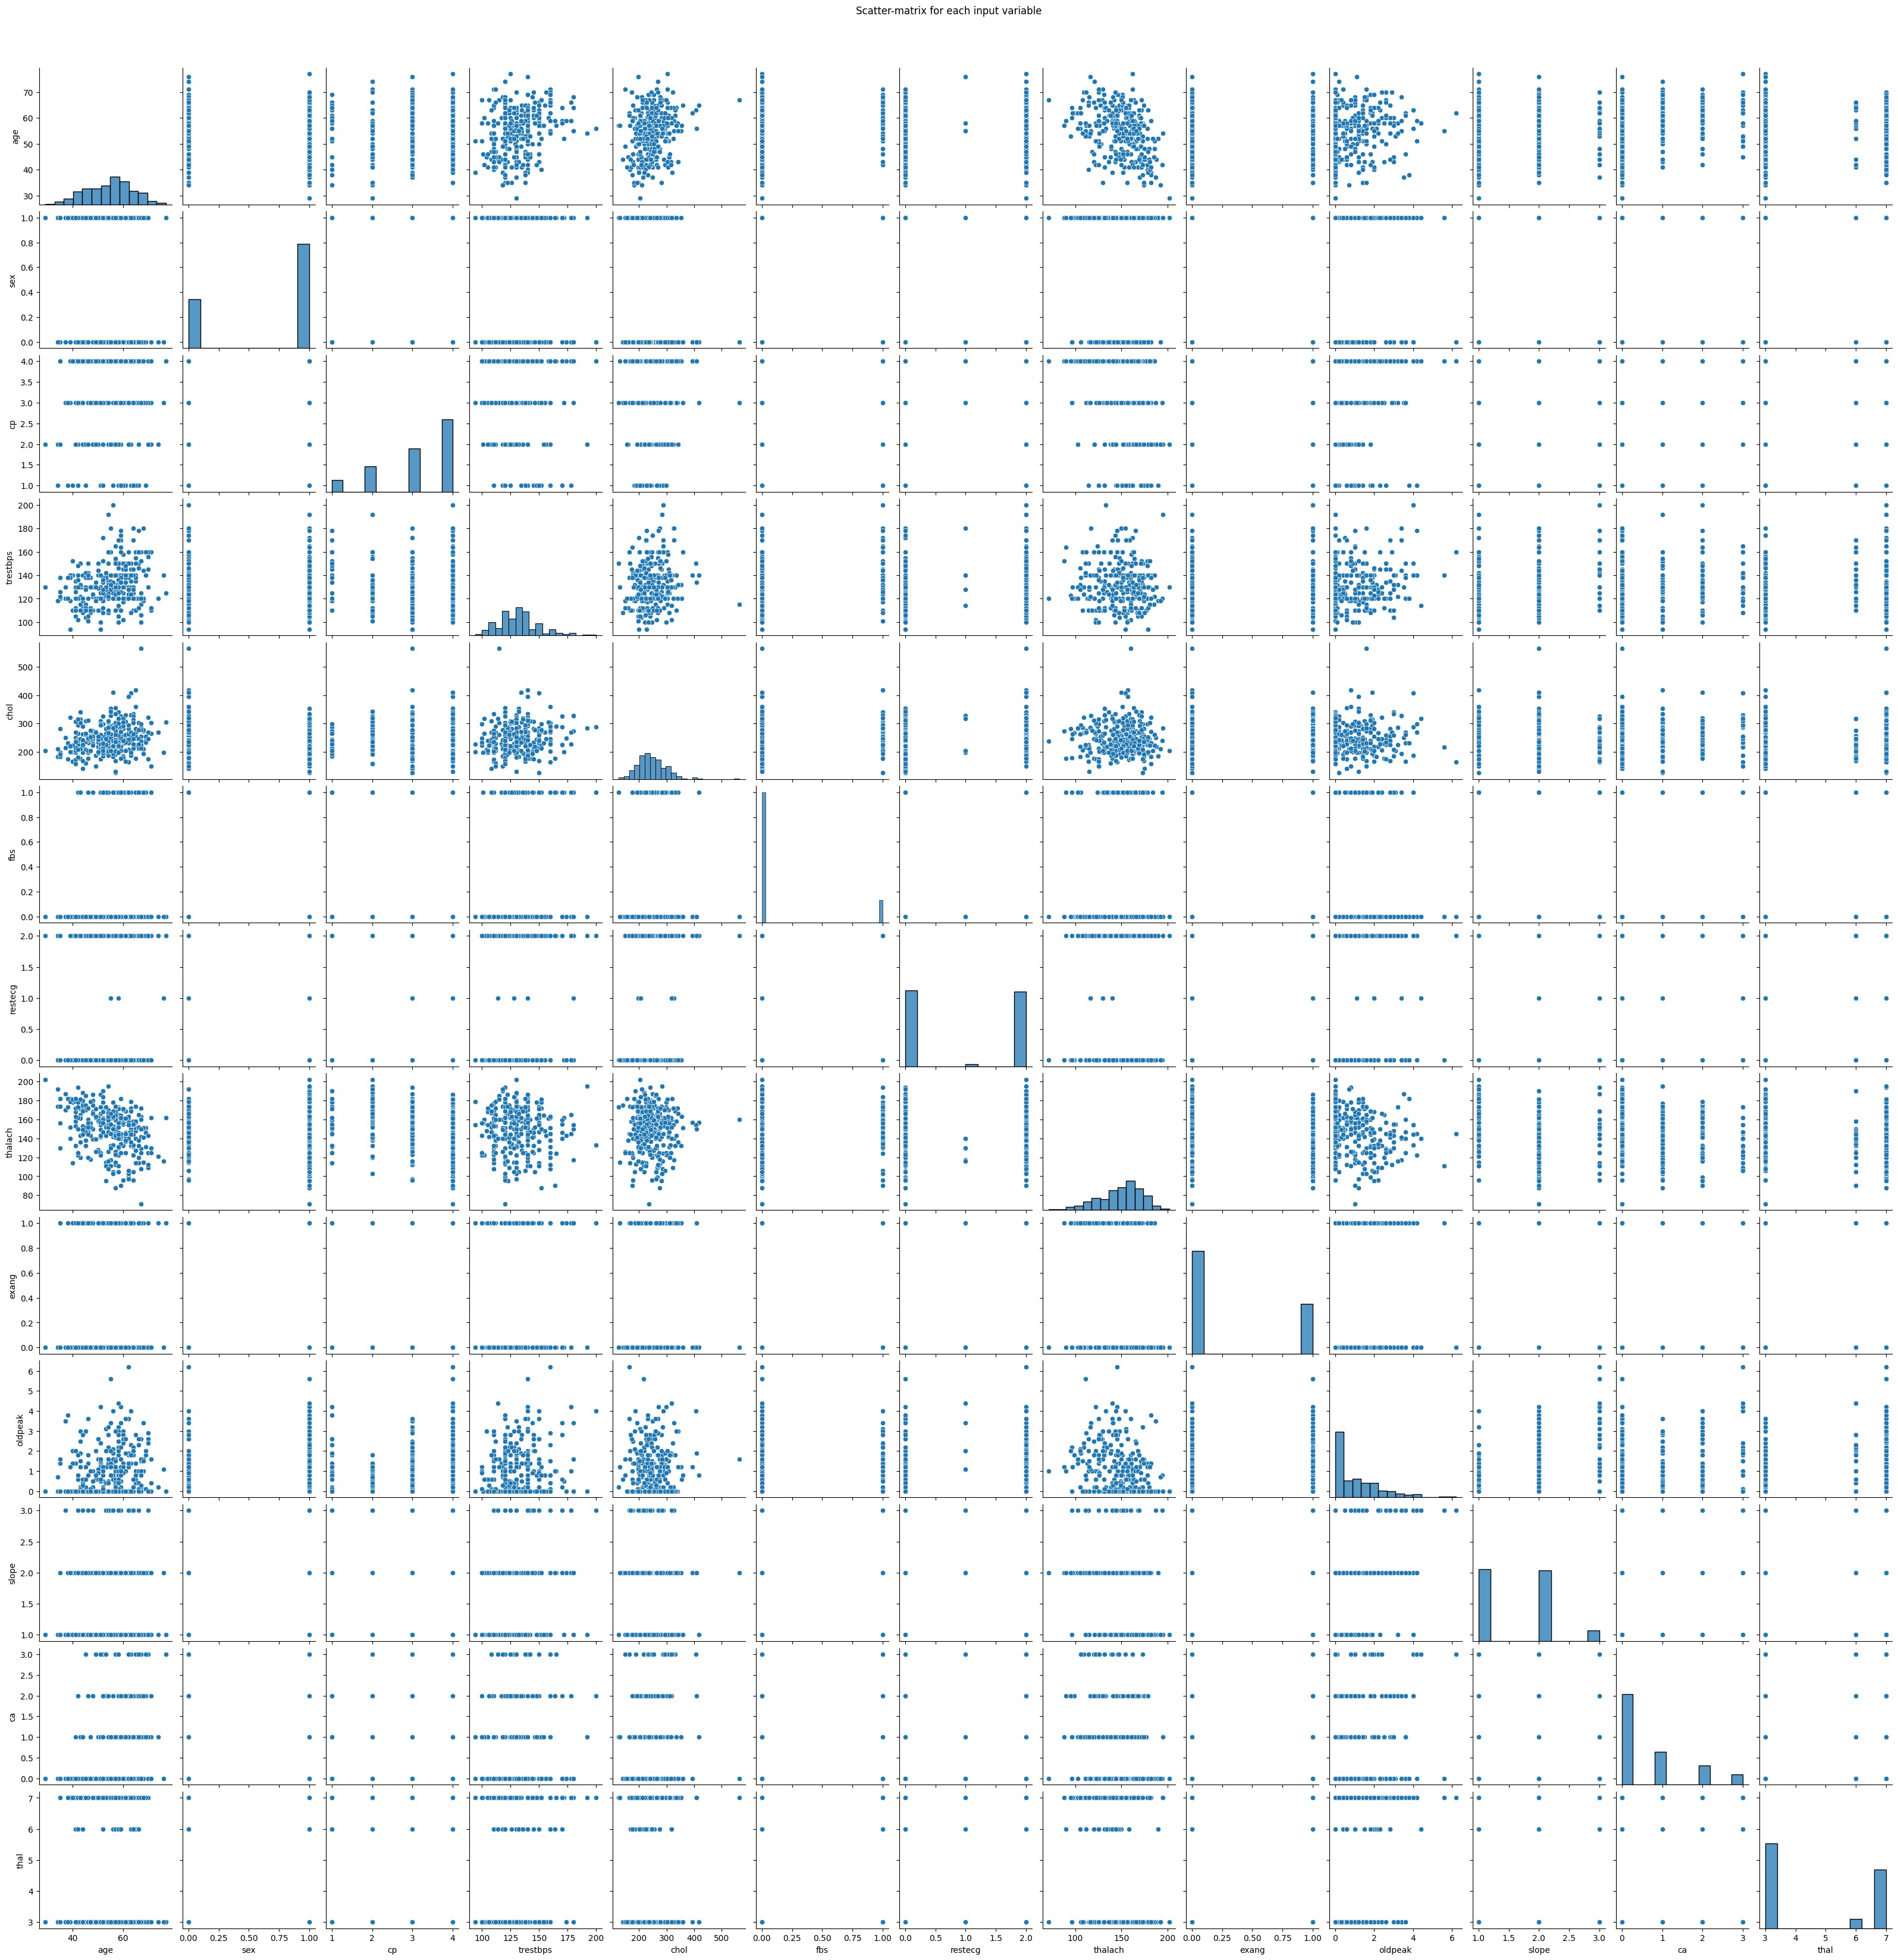

In [16]:
# Scatter-matrix
corr = sns.pairplot(df.drop("target", axis=1), diag_kind="hist")

corr.fig.suptitle("Scatter-matrix for each input variable", y=1.02)
plt.savefig("figures/task1_scatter_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

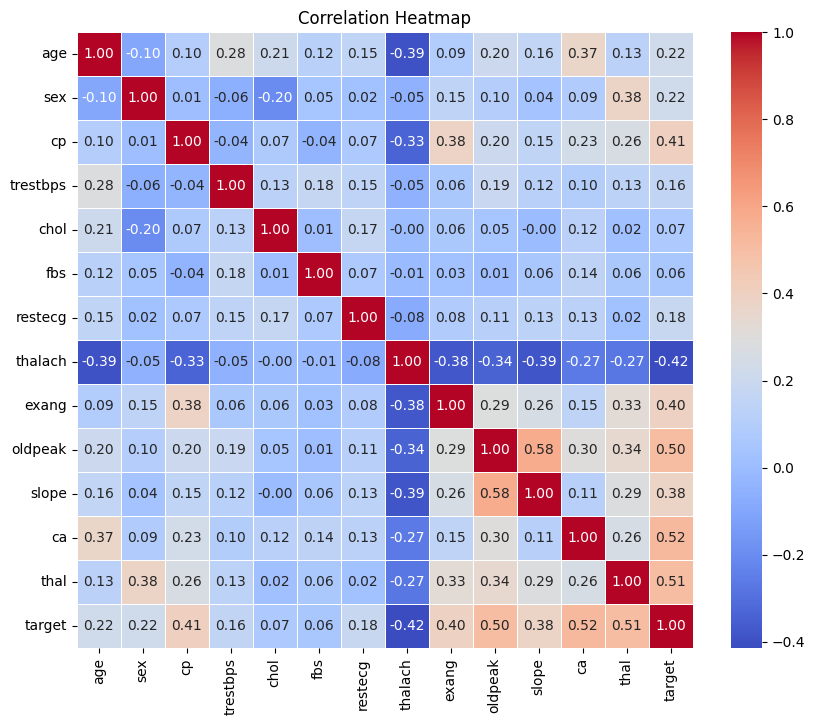

In [17]:
# Correlation matrix
corr = df.corr()

# Plot
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5, square=True)

plt.title("Correlation Heatmap")
plt.savefig("figures/task1_correlation_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

Most features show weak or no clear linear relationships, indicating low overall correlation between variables.
One noticeable pattern is a negative relationship between ``age`` and ``thalach``, suggesting that older patients tend to achieve lower maximum heart rates.

The scatter matrix includes both continuous and categorical variables. Categorical variables produce banded patterns due to their discrete values, while meaningful correlations are mainly observed among the continuous variables.

- **Keep the target column separate and do not use it during clustering.**

The target variable is kept separately and will be used later for evaluation purposes.
| Variable            |  meaning                                             |
| ------------------- | --------------------------------------------------- |
| **clustering_data** | data used to create clusters (without target column)                        |
| **evaluation_data** | target labels used later to evaluate the clustering |


In [18]:
clustering_data = df.drop("target", axis=1)
evaluation_data = df["target"]

In [19]:
# Controlling columns
print(clustering_data.columns)

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal'],
      dtype='object')


<a id='section32'></a>
### **Task 2 - Preprocessing & Feature Engineering**

- **Encode categorical features appropriately.**

As given above, the categorical (non-binary) variables in this dataset are: ``cp``, ``restecg``, ``slope`` and ``thal``. Which tactic to choose depends on whether the categories of our features are ordered or not. We should create dummy variables for all these features as there is no order, no relationship between the values chosen to represent the different categories.

In [20]:
# Categorical columns
cat_cols = ["cp", "restecg", "slope", "thal"]

# Encoding
encoder = OneHotEncoder(sparse_output=False, handle_unknown="ignore")
one_hot_encoded = encoder.fit_transform(clustering_data[cat_cols])

clustering_data_enc = pd.DataFrame(
    one_hot_encoded, columns=encoder.get_feature_names_out(cat_cols)
)
clustering_data_enc = pd.concat(
    [clustering_data.drop(cat_cols, axis=1), clustering_data_enc], axis=1
)

In [21]:
clustering_data_enc.columns

Index(['age', 'sex', 'trestbps', 'chol', 'fbs', 'thalach', 'exang', 'oldpeak',
       'ca', 'cp_1.0', 'cp_2.0', 'cp_3.0', 'cp_4.0', 'restecg_0.0',
       'restecg_1.0', 'restecg_2.0', 'slope_1.0', 'slope_2.0', 'slope_3.0',
       'thal_3.0', 'thal_6.0', 'thal_7.0'],
      dtype='object')

- **Normalise or standardise features. Justify your choice of method.**

For normalising/standardising we should first look at the data distribution of all the numerical columns.

- ``age``, ``thalach``: the column is approximately Gaussian distributed -> standardise
- ``trestbps``, ``chol``: values are right skewed -> log transformation and standardise

The variable ``oldpeak`` will be treated differently. This variable, referring to ST depression induced by exercise relative to rest, is 0 when the patient is most likely healthy and an integer when the patient most likely isn't healthy. Therefore we will proceed to create a binary variable version of ``oldpeak``, and in addition apply a logarithmic transformation and standardisation to the original column.

In [22]:
# Numerical columns
num_cols1 = ["age", "thalach"]
num_cols2 = ["trestbps", "chol"]
num_cols3 = ["oldpeak"]

# Log transformation for skewed features
clustering_data_enc[num_cols2] = np.log1p(clustering_data_enc[num_cols2])

# Create binary feature for oldpeak
clustering_data_enc["oldpeak_binary"] = (clustering_data_enc["oldpeak"] > 0).astype(int)
clustering_data_enc[num_cols3] = np.log1p(clustering_data_enc[num_cols3])

# Scaling
scaler = StandardScaler()
clustering_data_enc[num_cols1 + num_cols2 + num_cols3] = scaler.fit_transform(
    clustering_data_enc[num_cols1 + num_cols2 + num_cols3]
)

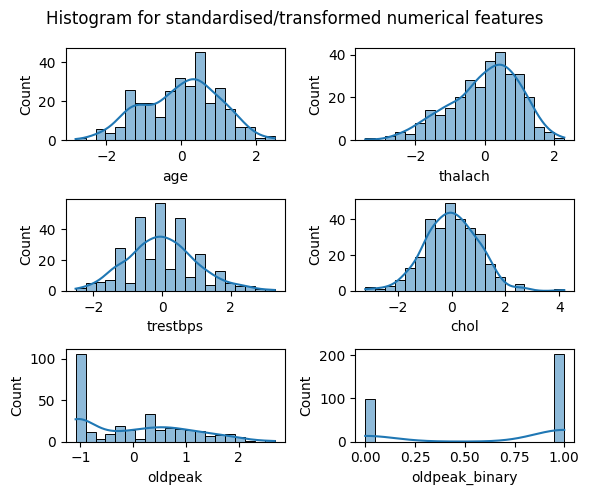

In [23]:
# Histograms for normalised/standardised numerical features
features = clustering_data_enc[num_cols1 + num_cols2 + num_cols3 + ["oldpeak_binary"]]
fig, axs = plt.subplots(3, 2, figsize=(6, 5))
axs = axs.ravel()

for i, col in enumerate(features.columns):
    sns.histplot(data=clustering_data_enc, x=col, ax=axs[i], kde=True, bins=20)

for j in range(len(features.columns), len(axs)):
    fig.delaxes(axs[j])

plt.suptitle("Histogram for standardised/transformed numerical features")
plt.tight_layout()
plt.savefig("figures/task2_histogram_numeric_features.png", dpi=150, bbox_inches="tight")
plt.show()

**Step A - PCA:**

*Note:* PCA is used here for visualisation purposes only. Clustering in Tasks 3–5 will be performed on the scaled feature set selected in Step B.

- **Plot the explained variance ratio per component and cumulatively.**

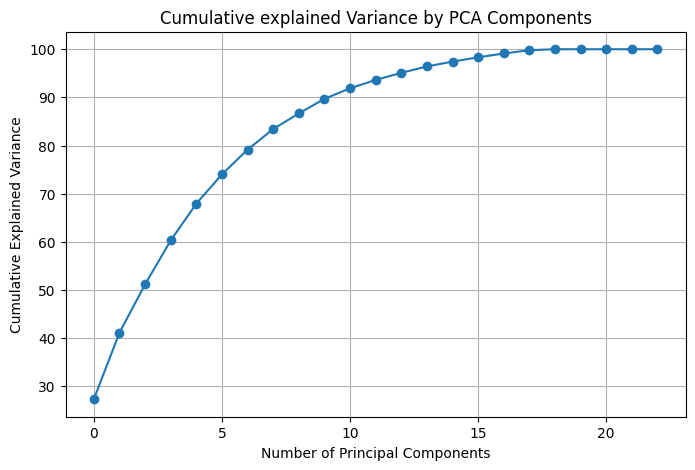

In [24]:
X = clustering_data_enc

pca = PCA()
pca.fit(X)

# Plot cumulative explained variance ratio
plt.figure(figsize=(8, 5))
plt.plot(np.cumsum((pca.explained_variance_ratio_) * 100), marker="o")
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Cumulative explained Variance by PCA Components")
plt.grid(True)
plt.savefig("figures/task2_cumulative_explained_variance_ratio.png", dpi=150, bbox_inches="tight")
plt.show()

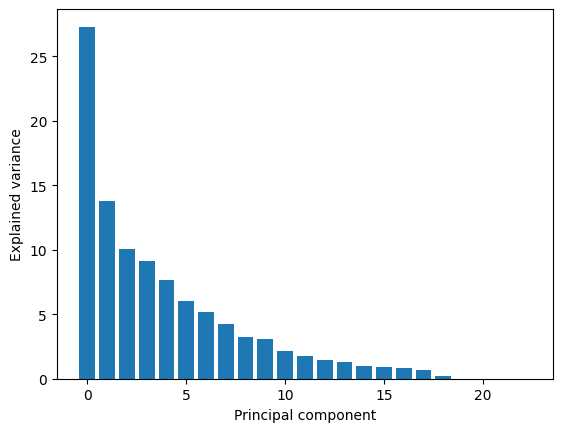

In [25]:
# Plot individual explained variance ratio
plt.bar(
    range(len(pca.explained_variance_ratio_)), (pca.explained_variance_ratio_) * 100
)
plt.xlabel("Principal component")
plt.ylabel("Explained variance")
plt.savefig("figures/task2_explained_variance_ratio.png", dpi=150, bbox_inches="tight")
plt.show()

- **Select the number of components that explain at least 85% of variance.**

In [26]:
X = clustering_data_enc
pca = PCA(n_components=0.85)
pca.fit_transform(X)
loadings = pd.DataFrame(
    abs(pca.components_.T),
    columns=[f"PC{i + 1}" for i in range(pca.n_components_)],
    index=X.columns,
)

print("These are the calculated components: \n", pca.components_)

These are the calculated components: 
 [[ 4.22005272e-01  2.09282528e-02  2.27959252e-01  1.46738840e-01
   2.51316921e-02 -4.57505148e-01  1.24279030e-01  4.69116201e-01
   3.44360569e-01  5.22709028e-03 -8.42642142e-02 -6.48564166e-02
   1.43893540e-01 -8.30090698e-02  1.04614928e-02  7.25475770e-02
  -1.89168629e-01  1.62833467e-01  2.63351618e-02 -1.52240167e-01
   2.47764820e-02  1.27463685e-01  1.91311869e-01]
 [ 3.21329738e-01 -1.14591439e-01  4.93857267e-01  6.15429723e-01
   4.14627985e-02  2.85395551e-01 -8.20660350e-02 -2.68631584e-01
   7.15823646e-02  1.27633212e-02  4.16059538e-02  2.50816444e-02
  -7.94509194e-02 -1.00580447e-01 -1.65514720e-03  1.02235595e-01
   1.41803381e-01 -1.22560870e-01 -1.92425113e-02  9.75281610e-02
  -2.31067709e-02 -7.44213901e-02 -1.15260794e-01]
 [-1.13562937e-01  4.21958835e-02  7.53354477e-01 -4.76743476e-01
   4.17517377e-02  1.97953908e-01 -2.42449672e-02  2.32912681e-01
  -2.62011159e-01  6.26674803e-02 -1.55380768e-02  2.92467788e-02
 

In [27]:
print(
    "The components we have found, explain the following percentage of variance: \n",
    pca.explained_variance_ratio_,
)

The components we have found, explain the following percentage of variance: 
 [0.27295537 0.13809745 0.10047821 0.09117121 0.07659331 0.06062845
 0.05152899 0.04267273 0.03237357]


In [28]:
print(
    "The number of components that explain at least 85% of variance: \n",
    len(pca.explained_variance_ratio_),
)

The number of components that explain at least 85% of variance: 
 9


- **Visualise the data in the first two principal components.**

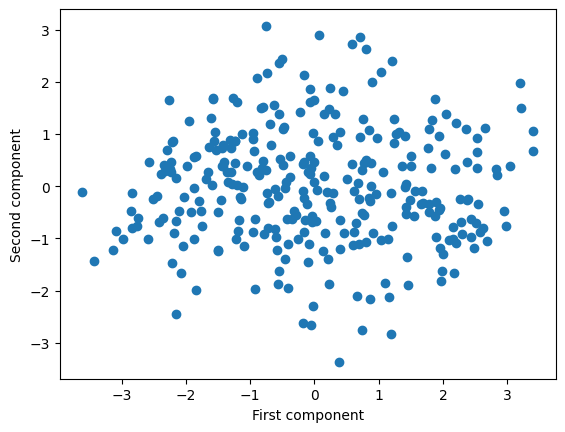

In [29]:
# Plot
X = clustering_data_enc
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)
plt.scatter(X_pca[:, 0], X_pca[:, 1])
plt.xlabel("First component")
plt.ylabel("Second component")
plt.savefig("figures/task2_pc1_pc2.png", dpi=150, bbox_inches="tight")
plt.show()

**Step B - Feature selection:**

- **Split the data into training and test sets before applying feature selection. This is the only step where the target label may be used - supervised feature selection methods (as covered in the course) require it. The test set and the target label must not be used again after this point.**

In [30]:
# Data split (80% train, 20% test)
X = clustering_data_enc
X_train, X_test, Y_train, Y_test = train_test_split(
    X, evaluation_data, test_size=0.2, shuffle=True, random_state=42
)

- **Apply at least one feature selection method covered in the course on the training set.**

In [31]:
# Configure to select all features
fs1 = SelectKBest(score_func=f_classif, k="all")
# Learn relationship from training data
fs1 = fs1.fit(X_train, Y_train)
# Transform train data
X_train_fs = fs1.transform(X_train)
# Transform test data
X_test_fs = fs1.transform(X_test)

In [32]:
# Get the pvalues
kbest_scores = -np.log10(fs1.pvalues_)
cols = fs1.get_support(indices=True)
# Selected_columns
print(cols)
# Normalize
kbest_scores /= kbest_scores.max()

[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22]


Number of features: 14


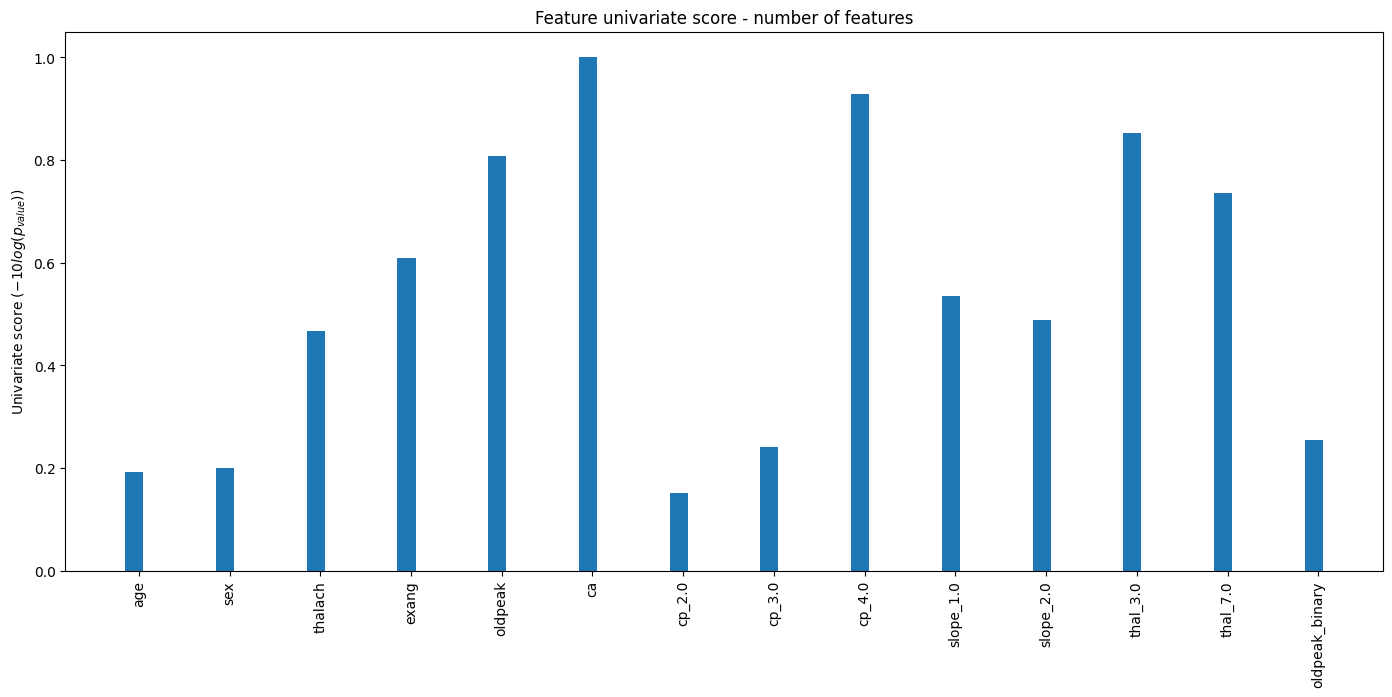

In [33]:
# Keep only the features with p-value below a threshold
cols = np.where(fs1.pvalues_ < 0.005)[0]
temp = X_train.iloc[:, cols]
X_indices = np.arange(temp.shape[-1])
print("Number of features:", temp.shape[1])

# Create the plot
plt.figure(figsize=(17, 7))
plt.figure(1)
plt.clf()
plt.bar(X_indices - 0.05, kbest_scores[cols], width=0.2)
plt.title("Feature univariate score - number of features")
plt.xticks(range(0, len(cols)), X_train.columns[cols], rotation=90)
plt.ylabel("Univariate score ($-10 log(p_{value})$)")
plt.savefig("figures/task2_selectkbest_features.png", dpi=150, bbox_inches="tight")
plt.show()

- **Compare the selected feature subset with the components identified by PCA. Do they capture similar structure?**

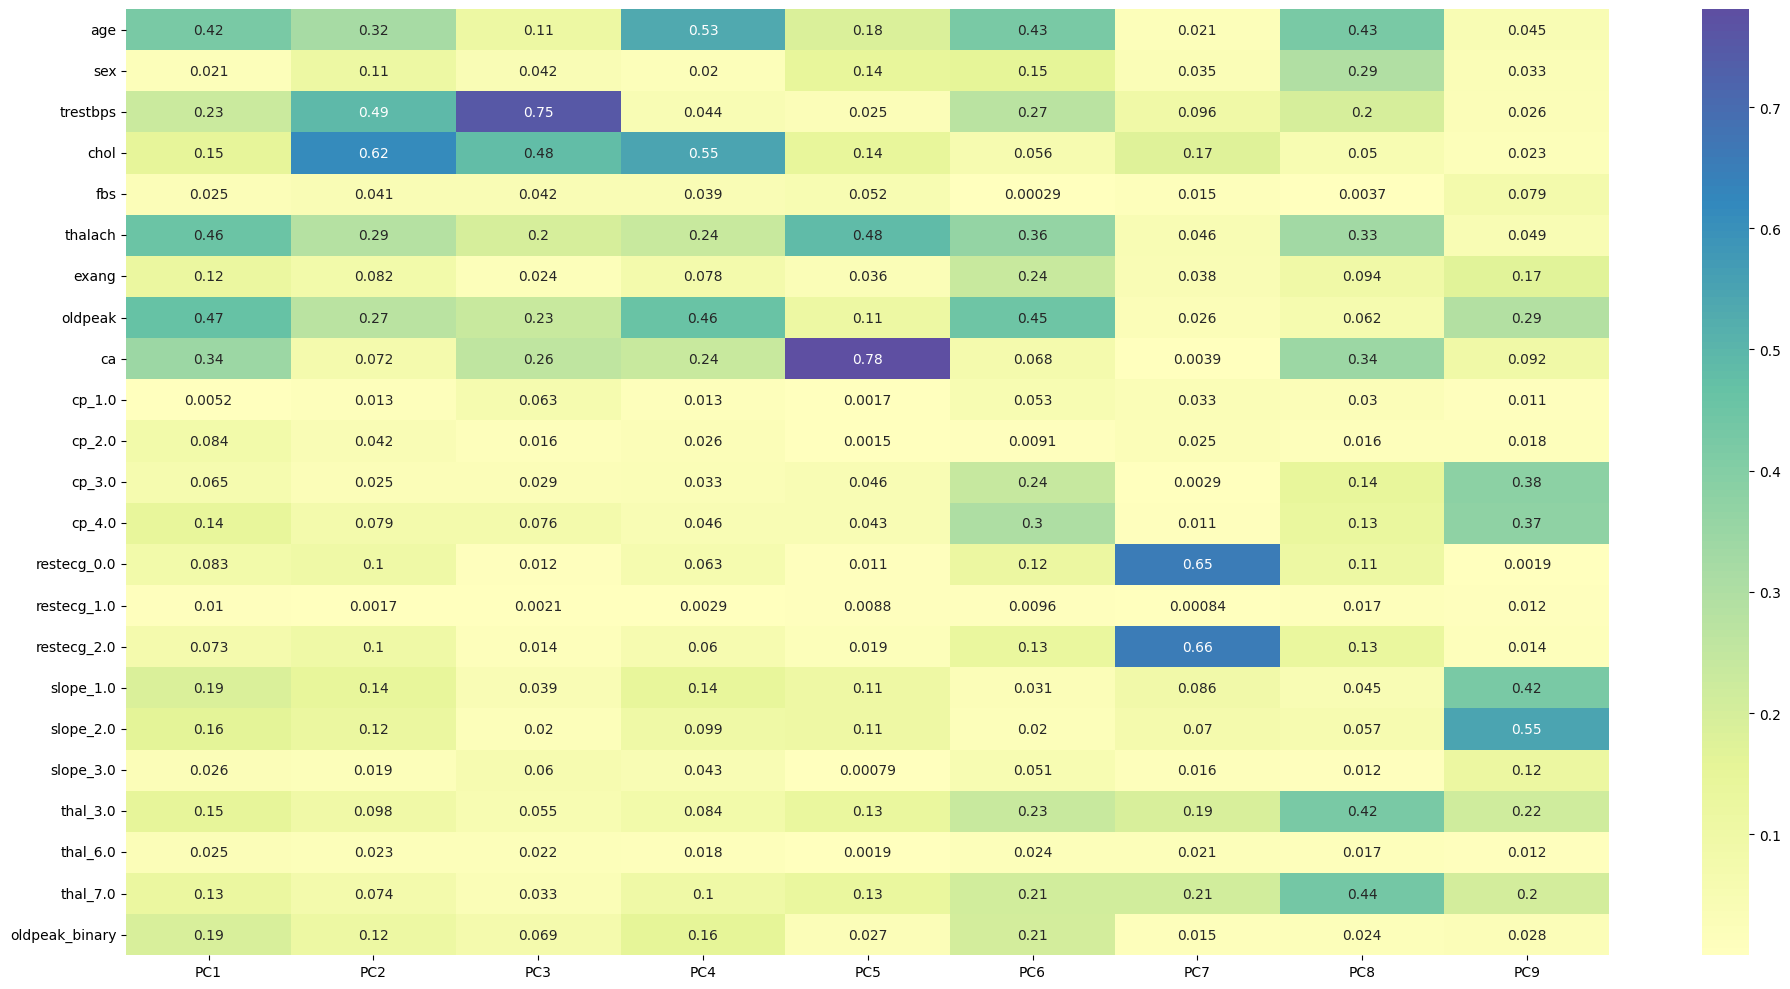

In [34]:
# Plot
plt.figure(figsize=(20, 10))
sns.heatmap(loadings, annot=True, cmap="Spectral", center=0)
plt.tight_layout()
plt.savefig("figures/task2_PCA_features.png", dpi=150, bbox_inches="tight")
plt.show()

In [35]:
loadings["sum"] = (
    loadings["PC1"]
    + loadings["PC2"]
    + loadings["PC3"]
    + loadings["PC4"]
    + loadings["PC5"]
    + loadings["PC6"]
    + loadings["PC7"]
    + loadings["PC8"]
    + loadings["PC9"]
)
loadings.sort_values("sum", ascending=False)

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,sum
age,0.422005,0.321330,0.113563,0.532537,0.184118,0.425783,0.021087,0.425750,0.044878,2.491052
thalach,0.457505,0.285396,0.197954,0.237813,0.484007,0.360096,0.046215,0.333411,0.048667,2.451065
oldpeak,0.469116,0.268632,0.232913,0.458893,0.110114,0.446509,0.025516,0.061976,0.290284,2.363953
chol,0.146739,0.615430,0.476743,0.545124,0.144300,0.056183,0.174139,0.050455,0.022840,2.231954
ca,0.344361,0.071582,0.262011,0.235870,0.780850,0.068094,0.003851,0.343587,0.092071,2.202278
trestbps,0.227959,0.493857,0.753354,0.044483,0.024763,0.273547,0.096479,0.200562,0.025948,2.140954
thal_3.0,0.152240,0.097528,0.054984,0.084355,0.133952,0.232674,0.190659,0.422579,0.215836,1.584808
thal_7.0,0.127464,0.074421,0.033004,0.102299,0.132042,0.208678,0.211586,0.439108,0.203665,1.532267
cp_4.0,0.143894,0.079451,0.076376,0.046176,0.043100,0.302495,0.010965,0.130208,0.374172,1.206837
slope_1.0,0.189169,0.141803,0.039388,0.142057,0.107213,0.030720,0.085972,0.044965,0.424148,1.205434


The most important features according to KBest: ``ca``, ``cp_4.0``, ``thal_3.0``, ``oldpeak``, ``thal_7.0``.
The most important features according to PCA: ``age``, ``thalach``, ``oldpeak``, ``chol``, ``ca``.

- **Justify which features you will retain for clustering, and why.**

The difference between the features identified by SelectKBest and PCA can be explained due to PCA not handling (encoded) categorical features very well. PCA is designed to work on numerical data and therefore, even though we technically can use (encoded) categorical columns in the analysis, the relationships are not really learnt very well.

Therefore, for clustering we propose retaining the variables ``cp``, ``ca``, ``thal``, ``oldpeak``, ``age``, ``chol``, and ``thalach``, as these are features identified by the two methods.

<a id='section33'></a>
### **Task 3 - Clustering: K-Means**

Based on the performed feature engineering, the selected features for clustering algorithms are cp, ca, thal, oldpeak, age, chol and thalach. Each one of them characterize different aspects of the status of patients with heart disease (as detailed in the table below).

| Features            | Interpretation                              |
| ------------------- | ------------------------------------------- |
| cp + thalach + age  | physiological patterns                      |
| ca + oldpeak        | strongest indicators of disease severity    |
| chol + thal         | underlying condition markers                |

Encoded categories should be included (ie. 'cp_1.0', 'cp_2.0', 'cp_3.0', 'cp_4.0', 'thal_3.0', 'thal_6.0' and 'thal_7.0'). However, one dummy categories must be dropped and be considered the baseline to avoid redundancy, artificial distance inflation and achieve better clustering stability. In this case, cp_1.0 and thal_6.0 are discarded because they do not appear in the KBest selection and have the lowest contributions on the first 2 PCA components. As a result, we obtain 10 final features as input to the clustering algorithms.

In [36]:
# Select features
selected_features = [
    'ca',
    'oldpeak',
    'thalach',
    'age',
    'chol',
    'cp_2.0', 'cp_3.0', 'cp_4.0',
    'thal_3.0', 'thal_7.0'
]

# Extract data
X = clustering_data_enc[selected_features]
print("We have imported {} data points of {} features each.".format(X.shape[0], X.shape[1]))
X_scaled = X.values

We have imported 303 data points of 10 features each.


We verify that features are properly standardized if:
- Mean ≈ 0
- Standard deviation ≈ 1 for continuous columns and small non-zero values for the binary ones.

In [37]:
# Sanity check
print("Per-feature means:\n", X.mean().round(4).to_string())
print("\nPer-feature stds:\n",  X.std().round(4).to_string())

Per-feature means:
 ca          0.6634
oldpeak    -0.0000
thalach    -0.0000
age        -0.0000
chol       -0.0000
cp_2.0      0.1650
cp_3.0      0.2838
cp_4.0      0.4752
thal_3.0    0.5545
thal_7.0    0.3861

Per-feature stds:
 ca          0.9344
oldpeak     1.0017
thalach     1.0017
age         1.0017
chol        1.0017
cp_2.0      0.3718
cp_3.0      0.4516
cp_4.0      0.5002
thal_3.0    0.4978
thal_7.0    0.4877


- **Apply K-Means for values of k from 2 to 10.**
- **Use the Elbow Method (inertia / cost) to identify the optimal k.**
- **Also compute the Silhouette Score for each k and plot it.**

KMeans algorithm was applied to the 303 observations and corresponding selected features, with a different number of clusters. Arguments init='k-means++' and max_iter=300 were selected by default, whereas n_init was set to 20 instead of 1 (default value for 'k-means++') to ensure stable results, reproducibility and better clustering quality.

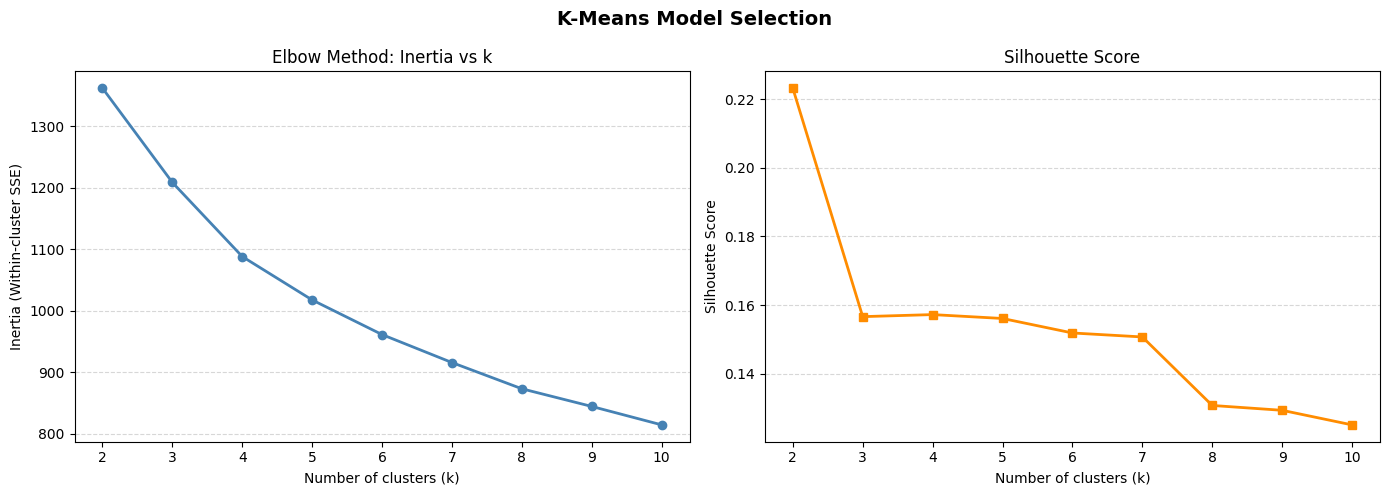

In [38]:
# Elbow Method (inertia vs k) and Silhouette Scores plots
 
k_range = range(2, 11)
inertias   = []
silhouettes = []
 
for k in k_range:
    km = KMeans(n_clusters=k, n_init=20, random_state=42)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))
 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("K-Means Model Selection", fontsize=14, fontweight="bold")
 
# Elbow curve
axes[0].plot(list(k_range), inertias, marker="o", linewidth=2, color="steelblue")
axes[0].set_title("Elbow Method: Inertia vs k")
axes[0].set_xlabel("Number of clusters (k)")
axes[0].set_ylabel("Inertia (Within-cluster SSE)")
axes[0].set_xticks(list(k_range))
axes[0].grid(axis="y", linestyle="--", alpha=0.5)
 
# Silhouette scores
axes[1].plot(list(k_range), silhouettes, marker="s", linewidth=2, color="darkorange")
axes[1].set_title("Silhouette Score")
axes[1].set_xlabel("Number of clusters (k)")
axes[1].set_ylabel("Silhouette Score")
axes[1].set_xticks(list(k_range))
axes[1].grid(axis="y", linestyle="--", alpha=0.5)
 
plt.tight_layout()
plt.savefig("figures/task3_kmeans_model_selection.png", dpi=150, bbox_inches="tight")
plt.show()

The Elbow method consisted on computing the Sum of Squared Errors (SSE) (also called inertia) based on the number of clusters (k). It is used to find the most optimal number of clusters for a given dataset. As can be seen from the graph on the right, the inertia curve bends around k = 3-4, afterwards the rate of decrease slows down. In addition, the Silhouette score plot present its peak at k = 2 with a value of 0.22. Nevertheless, the elbow method indicates a more informative structure around k = 3, which is near to the Silhouette's peak. Therefore, we selected k = 3 as it provides a balance between cluster compactness and meaningful subgroup differentiation.

In [39]:
# Criteria: Both plots produced and interpreted.
## Optimal k selected with justification.



- **Fit the final K-Means model with your chosen k and visualize the clusters in PCA space.**


Chosen k = 3
  Inertia  : 1208.38
  Silhouette: 0.1567

Cluster sizes:
0    100
1     97
2    106


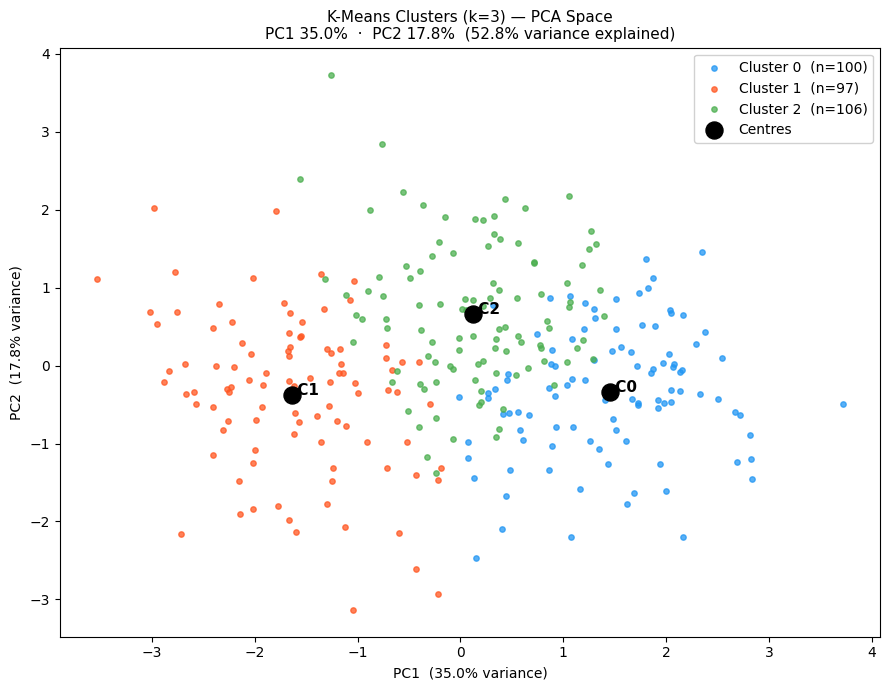

In [40]:
k_optimal = 3
print(f"\nChosen k = {k_optimal}")
print(f"  Inertia  : {inertias[k_optimal - 2]:.2f}")
print(f"  Silhouette: {silhouettes[k_optimal - 2]:.4f}")
 
# Fit final model 
km_final = KMeans(n_clusters=k_optimal, n_init=50, random_state=42)
km_cluster_labels = km_final.fit_predict(X_scaled)

print(f"\nCluster sizes:\n{pd.Series(km_cluster_labels).value_counts().sort_index().to_string()}")

# Add labels to the feature dataframe
X_df = pd.DataFrame(X_scaled, columns=selected_features)
X_df["cluster"] = km_cluster_labels
 
# PCA projection (2-D) for visualisation
 
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
 
explained = pca.explained_variance_ratio_
 
# Project cluster centres into PCA space
centres_pca = pca.transform(km_final.cluster_centers_)
 
fig, ax = plt.subplots(figsize=(9, 7))
 
palette = ["#2196F3", "#FF5722", "#4CAF50", "#9C27B0",
           "#FFC107", "#00BCD4", "#E91E63", "#8BC34A", "#FF9800"]
 
for c in range(k_optimal):
    mask = km_cluster_labels == c
    ax.scatter(
        X_pca[mask, 0], X_pca[mask, 1],
        s=60, alpha=0.75,
        marker='.',
        color=palette[c],
        label=f"Cluster {c}  (n={mask.sum()})"
    )
 
# Plot centre markers
ax.scatter(
    centres_pca[:, 0], centres_pca[:, 1],
    s=150, marker='o', color="black", zorder=5, label="Centres"
)
for i, (cx, cy) in enumerate(centres_pca):
    ax.annotate(f" C{i}", (cx, cy), fontsize=11, fontweight="bold")
 
ax.set_title(
    f"K-Means Clusters (k={k_optimal}) — PCA Space\n"
    f"PC1 {explained[0]*100:.1f}%  ·  PC2 {explained[1]*100:.1f}%  "
    f"({(explained[0]+explained[1])*100:.1f}% variance explained)",
    fontsize=11
)
ax.set_xlabel(f"PC1  ({explained[0]*100:.1f}% variance)")
ax.set_ylabel(f"PC2  ({explained[1]*100:.1f}% variance)")
ax.legend(framealpha=0.9)
 
plt.tight_layout()
plt.savefig("figures/task3_pca_clusters.png", dpi=150, bbox_inches="tight")
plt.show()

The three clusters are well-balanced (100, 97 and 106). Also, the 2D PCA plot captures 52.8% of the total structure.  
The centers of each cluster are reported with the scaled selected features prior to interpreting their values.

In [41]:
# Cluster centres in original scaled feature space
centres_df = pd.DataFrame(km_final.cluster_centers_, columns=selected_features)
centres_df.index = [f"Cluster {i}" for i in range(k_optimal)]
display(centres_df)

,ca,oldpeak,thalach,age,chol,cp_2.0,cp_3.0,cp_4.0,thal_3.0,thal_7.0
Cluster 0,0.130000,-0.405787,0.694162,-1.052662,-0.414434,0.260000,0.400000,0.270000,0.760000,0.210000
Cluster 1,1.381443,0.995286,-0.885200,0.521446,0.020376,0.020619,0.134021,0.783505,0.237113,0.639175
Cluster 2,0.509434,-0.527963,0.155171,0.515906,0.372329,0.207547,0.311321,0.386792,0.650943,0.320755


In [42]:
# Criteria: Cluster assignments plotted in PCA space. Centres reported.



- **Visualise the cluster assignments by projecting the data into PCA space (2D). Report and interpret the cluster centres directly in the original feature space, which features are highest or lowest for each group?**

In [43]:
# Per-cluster means in original (unscaled) space
X_orig = pd.DataFrame(X_scaled, columns=selected_features)
X_orig["cluster"] = km_cluster_labels
 
cluster_means = X_orig.groupby("cluster")[selected_features].mean()
print("\nCluster means (scaled values)")
print(cluster_means.T.to_string())


Cluster means (scaled values)
cluster          0         1         2
ca        0.130000  1.381443  0.509434
oldpeak  -0.405787  0.995286 -0.527963
thalach   0.694162 -0.885200  0.155171
age      -1.052662  0.521446  0.515906
chol     -0.414434  0.020376  0.372329
cp_2.0    0.260000  0.020619  0.207547
cp_3.0    0.400000  0.134021  0.311321
cp_4.0    0.270000  0.783505  0.386792
thal_3.0  0.760000  0.237113  0.650943
thal_7.0  0.210000  0.639175  0.320755


Taking into account that features are z-scored, then positive values refers those above average, while negative values are assigned to those below the dataset mean.

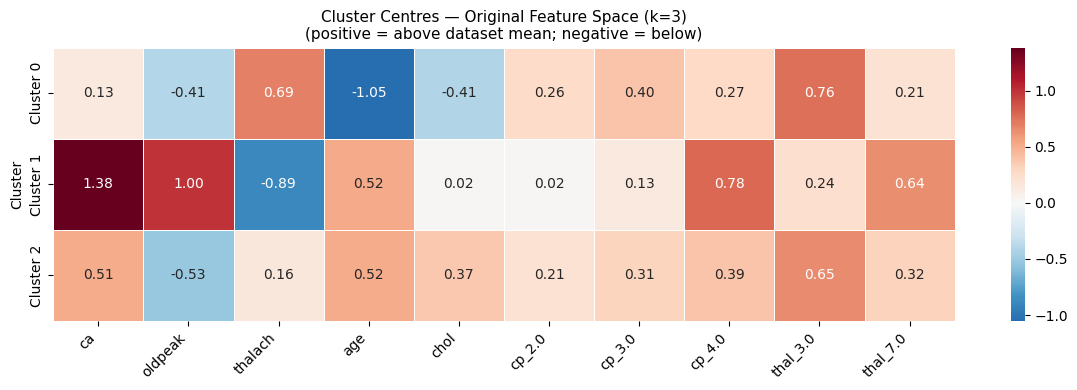


Key features per cluster:

Cluster 0:
  Highest  : thal_3.0, thalach, cp_3.0
  Lowest   : age, chol, oldpeak

Cluster 1:
  Highest  : ca, oldpeak, cp_4.0
  Lowest   : thalach, chol, cp_2.0

Cluster 2:
  Highest  : thal_3.0, age, ca
  Lowest   : oldpeak, thalach, cp_2.0


In [44]:
# Heatmap of cluster centres
fig, ax = plt.subplots(figsize=(12, 4))
 
sns.heatmap(
    centres_df,
    annot=True, fmt=".2f",
    cmap="RdBu_r", center=0,
    linewidths=0.5, linecolor="white",
    ax=ax
)
ax.set_title(
    f"Cluster Centres — Original Feature Space (k={k_optimal})\n"
    "(positive = above dataset mean; negative = below)",
    fontsize=11
)
ax.set_ylabel("Cluster")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("figures/task3_cluster_centres_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
 
# Highest and lowest feature per cluster
print("\nKey features per cluster:")
for idx, row in centres_df.iterrows():
    top3    = row.nlargest(3).index.tolist()
    bottom3 = row.nsmallest(3).index.tolist()
    print(f"\n{idx}:")
    print(f"  Highest  : {', '.join(top3)}")
    print(f"  Lowest   : {', '.join(bottom3)}")

Cluster 0 represents a low-risk group composed mainly of **younger individuals, as reflected by their below-average age values**. This group shows relatively **low ST depression during exercise (`oldpeak`)**, indicating minimal ischemic response, and high maximum heart rates (`thalach`), suggesting good cardiovascular fitness. **Their cholesterol (`chol`) is lower than average**, and the number of major vessels colored by fluoroscopy (`ca`) is near the dataset mean, pointing to minimal arterial blockage. In terms of chest pain type (`cp`), this cluster has higher proportions of **non-anginal or atypical pain**, and most individuals have **normal thalassemia results (`thal = 3`)**. Overall, this cluster corresponds to patients with favorable cardiovascular health and minimal risk of heart disease.

Cluster 1 represents a high-risk group with multiple indicators of cardiovascular disease. Individuals in this cluster are older and have a significantly **elevated number of major vessels colored (`ca`)**, suggesting severe coronary artery disease. **Their `oldpeak` values are high**, reflecting ST depression during exercise, and `thalach` values are low, indicating poor exercise tolerance. The chest pain type **(`cp`) is predominantly type 4, asymptomatic**, which is often associated with more severe underlying disease, and abnormal thalassemia results (`thal = 7`) are common. Collectively, these features define Cluster 1 as the group most likely to have diagnosed or advanced heart disease.

Cluster 2 corresponds to an intermediate-risk group with mixed clinical characteristics. While **individuals in this cluster are older**, like those in Cluster 1, their **`oldpeak` values are below average**, suggesting less ischemic response during exercise, and `thalach` is near the mean, indicating moderate cardiovascular fitness. Cholesterol (`chol`) is slightly elevated, and **the number of major vessels (`ca`) is moderately high**, reflecting some arterial blockage but less severe than Cluster 1. Chest pain types in this group are more often non-anginal or atypical (`cp = 2 or 3`), and a relatively high proportion have **normal thalassemia results (`thal = 3`)**. This cluster represents patients with some risk factors but without the severe pathological features observed in the high-risk group.

In [45]:
clustering_data_kmeans = clustering_data.copy()

clustering_data_kmeans['cluster_kmeans'] = km_cluster_labels

mean_clusters_kmeans = clustering_data.groupby(
    clustering_data_kmeans["cluster_kmeans"]
).mean()
display(mean_clusters_kmeans)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
cluster_kmeans,,,,,,,,,,,,,
0,44.94000,0.720000,2.870000,125.420000,225.290000,0.100000,0.700000,165.460000,0.150000,0.602000,1.440000,0.130000,3.930000
1,59.14433,0.783505,3.639175,135.309278,248.195876,0.164948,1.175258,129.391753,0.577320,2.163918,2.000000,1.381443,5.927835
2,59.09434,0.547170,2.990566,134.292453,265.509434,0.179245,1.094340,153.150943,0.264151,0.423585,1.386792,0.509434,4.367925


Feature table:

|**Feature** |**Name**                |**Description**                                             |  
|------------|------------------------|------------------------------------------------------------|  
|``age``     |Age                     |Age in years                                                |  
|``sex``     |Sex                     |1 = male, 0 = female                                        |  
|``cp``      |Chest pain type         |4 types: 1 (typical angina), 2 atypical angina), 3 (non-anginal pain) and 4 (asymptomatic)    |  
|``trestbps``|Resting blood pressure  |mm Hg on admission                                          |  
|``chol``    |Serum cholesterol|mg/dl |mg/dl                                                       |  
|``fbs``     |Fasting blood sugar     | >120mg/dl: 1 = true, 0 = false                             |  
|``restecg`` |Resting ECG results     |Values 0 (normal), 1 (ST-T wave abnormality), 2 (probable or definite left ventricular hypertrophy)    |  
|``thalach`` |Max heart rate achieved |Numeric                                                     |  
|``exang``   |Exercise-induced angina |1 = yes, 0 = no                                             |  
|``oldpeak`` |ST depression           |Induced by exercise vs. rest                                |  
|``slope``   |Slope of peak ST segment|Values 1 (upsloping), 2 (flat), 3 (downsloping)                                              |  
|``ca``      |Major vessels (0-3)     |Coloured by fluoroscopy                                     |  
|``thal``    |Thal                    |3 = normal, 6 = fixed defect, 7 = reversible defect         |  

Summary table of results:

| Feature         | Cluster 0 (Low risk) | Cluster 1 (High risk) | Cluster 2 (Medium risk) |
| --------------- | -------------------- | --------------------- | ----------------------- |
| Age             | Young                | Old                   | Old                     |
| Heart rate (``thalac``)      | High (good)          | Low (poor)            | Medium                  |
| ST depression (``oldpeak``)   | Low                  | Very high             | Low                     |
| Exercise angina (``exang``) | Rare                 | Very common           | Moderate                |
| Vessel blockage (``ca``)| Minimal              | High                  | Moderate                |

**Cluster 0** is characterized by **younger individuals (mean age ≈ 44.94) with relatively favorable clinical values**, including lower resting blood pressure (trestbps=125.42 mmHg) and cholesterol levels (225.29 mg/dl), **high maximum heart rate (thalac=165.46)**, and low exercise-induced angina (exang=0.15) and ST depression (oldpeak ≈ 0.60). The average number of affected vessels is minimal (ca ≈ 0.13), and thal values (≈ 3.93) are close to normal. In contrast, **Cluster 1 shows higher-risk numerical patterns**, with **older individuals** (age ≈ 59.14), elevated blood pressure (135.31 mmHg) and cholesterol (248.20 mg/dl), the lowest maximum heart rate (129.39), and the highest levels of exercise-induced angina (0.58) and ST depression (2.16). This cluster also has the highest vessel involvement (ca ≈ 1.38) and more abnormal thal values (≈ 5.93). **Cluster 2 presents intermediate characteristics**, with a **similar age to Cluster 1** (≈ 59.09) but slightly lower blood pressure (134.29 mmHg) and the highest cholesterol levels (265.51 mg/dl). It shows moderate maximum heart rate (153.15), intermediate exercise angina (0.26), low ST depression (0.42), and moderate vessel involvement (ca ≈ 0.51), along with mildly abnormal thal values (≈ 4.37).

In [46]:
# Criteria: Feature-level description of each cluster provided.



<a id='section34'></a>
### **Task 4 - Clustering: Gaussian Mixture Models**

- **Fit GMMs with a varying number of components (2 to 10).**

GMM uses the Expectation-Maximization (EM) algorithm to fit a probabilistic model where each cluster is a Gaussian distribution. Unlike K-Means, which assigns each point to exactly one cluster, GMM assigns probabilities of belonging to each component.

First, we choose the features identified during the feature engineering stage: ``cp``, ``ca``, ``thal``, ``oldpeak``, ``age``, ``chol``, and ``thalach``.

Since GMM assume continuous variables, including all dummy variables for a categorical feature can introduce linear dependence. Therefore, for the categorical features ``ca`` and ``thal``, we drop one dummy variable from each to avoid this issue.

In [47]:
# Selected features for GMM clustering
selected_features = [
    "cp_2.0",  # drop cp_1.0
    "cp_3.0",
    "cp_4.0",
    "thal_6.0",  # drop thal_3.0
    "thal_7.0",
    "ca",
    "oldpeak",
    "age",
    "chol",
    "thalach",
]

X_gmm = clustering_data_enc[selected_features]

In [48]:
# Number of components to try
n_components = range(2, 11)

gmm_models = {}
bic_scores = []
aic_scores = []
cluster_labels = {}

# Fit GMM
for n in n_components:
    gmm = GaussianMixture(
        n_components=n,
        random_state=42,
    )

    gmm.fit(X_gmm)

    # Store model
    gmm_models[n] = gmm

    # Store metrics
    bic_scores.append(gmm.bic(X_gmm))
    aic_scores.append(gmm.aic(X_gmm))

    # Store cluster assignments
    cluster_labels[n] = gmm.predict(X_gmm)

- **Use BIC or AIC to select the optimal number of components. Plot the selected method curve.**

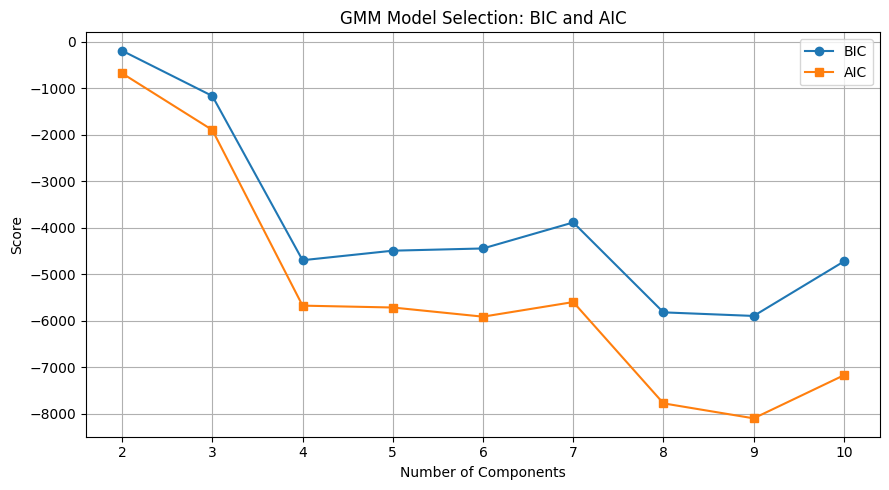

In [49]:
# Plot BIC and AIC
plt.figure(figsize=(9, 5))
plt.plot(n_components, bic_scores, marker="o", label="BIC")
plt.plot(n_components, aic_scores, marker="s", label="AIC")
plt.xlabel("Number of Components")
plt.ylabel("Score")
plt.title("GMM Model Selection: BIC and AIC")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("figures/task4_GMM_model_selection.png", dpi=150, bbox_inches="tight")
plt.show()

To select the best number of components, we will use the Bayesian Information Criterion (BIC). BIC scores a model by balancing how well it fits the data against how complex it is.

The lower BIC, the better model (penalizes both poor fit and unnecessary complexity).

In [50]:
# Select lowest BIC score
best_n = n_components[np.argmin(bic_scores)]
print("Best number of components based on BIC:", best_n)

Best number of components based on BIC: 9


- **Visualise the cluster assignments by projecting the data into PCA space (2D). Report and interpret the cluster centres directly in the original feature space, which features are highest or lowest for each group?**

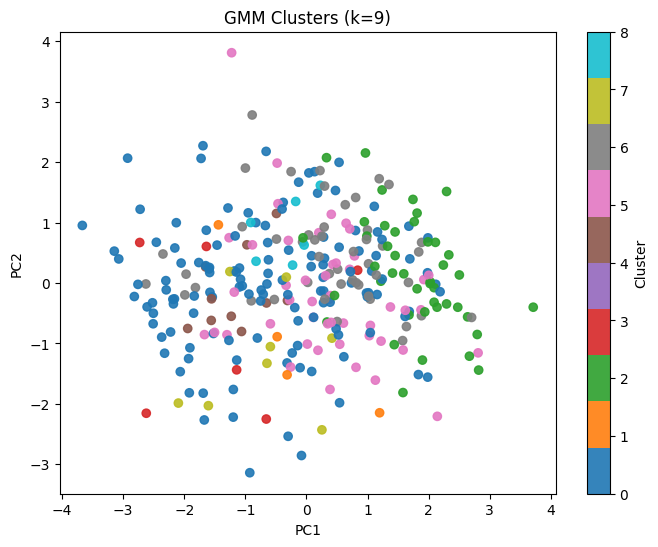

In [51]:
# Plot PCA
best_gmm = gmm_models[best_n]
best_labels = cluster_labels[best_n]

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_gmm)

plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=best_labels, cmap="tab10", alpha=0.9)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title(f"GMM Clusters (k={best_n})")
plt.colorbar(label="Cluster")
plt.savefig("figures/task4_GMM_clusters.png", dpi=150, bbox_inches="tight")
plt.show()

In [52]:
# Cluster centers
cluster_centers = pd.DataFrame(best_gmm.means_, columns=selected_features)
cluster_centers.index.name = "Cluster"
display(cluster_centers)

,cp_2.0,cp_3.0,cp_4.0,thal_6.0,thal_7.0,ca,oldpeak,age,chol,thalach
Cluster,,,,,,,,,,
0,0.000000,0.000000,1.000000,0.000000,0.592308,0.900001,0.230845,0.126110,0.138089,-0.339508
1,0.250000,0.500000,0.250000,0.000000,0.250000,0.750000,-0.914634,0.754793,-1.240627,-1.099401
2,0.445464,0.531089,0.000000,0.046893,0.000000,0.000000,-1.088782,-0.772671,-0.205658,0.717464
3,0.166668,0.333336,0.333327,0.333336,0.333327,2.833332,0.800731,-0.011711,-0.671860,-0.362301
4,0.000000,0.100000,0.400000,0.600000,0.000000,1.400000,0.865185,0.937645,-0.212413,-0.026591
5,0.000000,0.731110,0.000000,0.000000,0.372289,0.000000,0.359342,-0.012745,-0.154112,0.241733
6,0.604149,0.395851,0.000000,0.000000,0.395834,0.833289,-0.198875,-0.011720,0.254174,0.424965
7,0.000000,0.000000,0.875000,0.875000,0.000000,0.625000,0.531992,-0.173314,-0.669742,-1.214345
8,0.000000,0.666667,0.000000,0.166667,0.000000,0.833334,-0.908792,1.133425,0.424236,-0.333107


In [53]:
# Cluster Analysis
for cluster_id in range(best_n):
    n_members = np.sum(best_labels == cluster_id)
    print(f"\nCluster {cluster_id} (n={n_members})")


Cluster 0 (n=130)

Cluster 1 (n=4)

Cluster 2 (n=43)

Cluster 3 (n=6)

Cluster 4 (n=10)

Cluster 5 (n=48)

Cluster 6 (n=48)

Cluster 7 (n=8)

Cluster 8 (n=6)


- Cluster 0 (n=130): is the largest group. It is defined by high ``cp_4.0`` (asymptomatic chest pain), elevated ``ca`` and ``oldpeak``, and low ``thalach``. 

- Cluster 1 (n=4): is a small group. It has high ``age`` (old patients), but low ``chol``, ``thalach``, and ``oldpeak``. 

- Cluster 2 (n=43): it has younger patients (``age`` below mean) with high ``thalach``, low ``oldpeak``, low ``ca``, and low ``cp_4.0``. 

- Cluster 3 (n=6): ``ca`` is the highest of any cluster. It also has elevated ``oldpeak`` but low ``chol``.

- Cluster 4 (n=10): older patients with high ``oldpeak``, ``ca``, and ``thal_6.0``. Low ``chol``.

- Cluster 5 (n=48): high ``cp_3.0`` (non-anginal pain) and elevated ``oldpeak``, but low ``ca`` and ``chol``.

- Cluster 6 (n=48): high ``cp_2.0`` (atypical angina) and high ``thalach``, with low ``oldpeak``. 

- Cluster 7 (n=8): very low ``thalach`` (lowest of all clusters) and high ``thal_6.0``(fixed defect), with elevated ``oldpeak``. 

- Cluster 8 (n=6): the oldest cluster on average with high ``chol`` but very low ``oldpeak`` and low ``thalach``. 

- **Compare the hard cluster assignments from GMM with K-Means. Where do they agree and disagree?**

In [54]:
# Criteria: Agreements and disagreements discussed with examples.


<a id='section35'></a>
### **Task 5 - Clustering: Hierarchical Clustering**

- **Compute a dendrogram using at least two linkage methods (e.g. Ward, complete, average).**

In [55]:
selected_features = [
    'ca',
    'oldpeak',
    'thalach',
    'age',
    'chol',
    'cp_2.0', 'cp_3.0', 'cp_4.0',
    'thal_3.0', 'thal_7.0'
]

X_hier = clustering_data_enc[selected_features]

In these dendrograms we can observe how the 303 observations are merged into clusters using the hierarchical clustering algorithm. Two different linkage methods were used for this purpose: Ward and Complete. The Ward method performs merges by minimizing the increase in within-cluster variance, which usually produces more compact groups. On the other hand, the Complete method performs merges based on the maximum distance between observations from different clusters, which tends to produce more separated clusters.

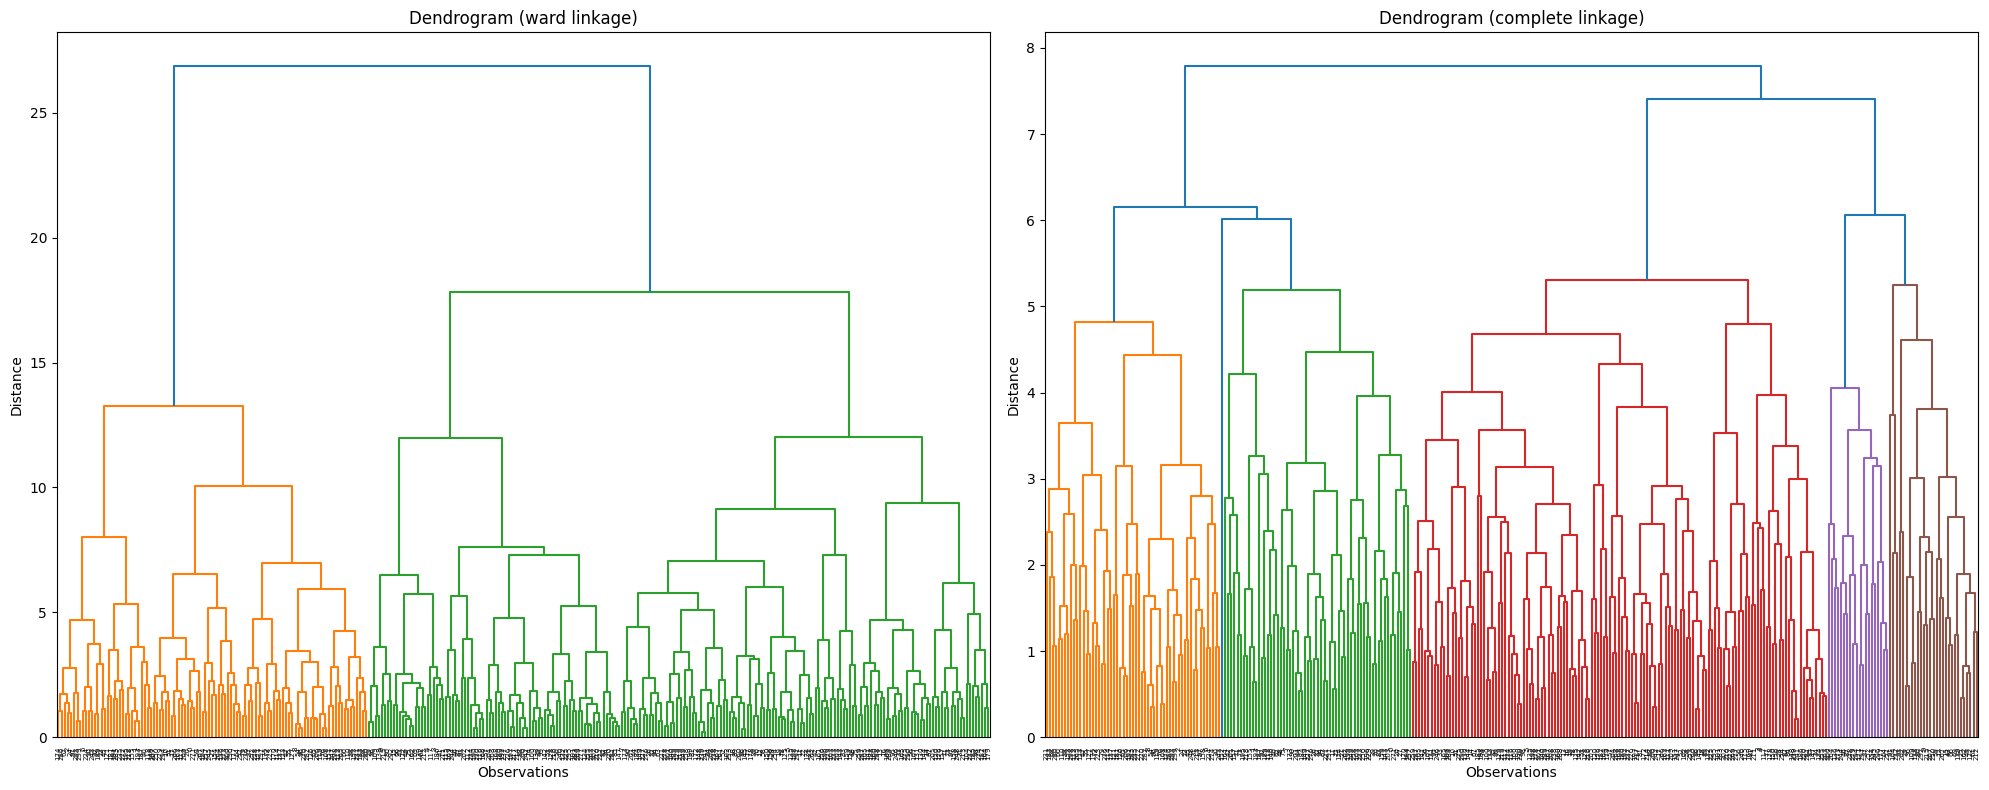

In [56]:
Z_ward = linkage(X_hier, method="ward")
Z_complete = linkage(X_hier, method="complete")

fig = plt.figure(figsize=(20, 8))

ward = fig.add_subplot(1, 2, 1)
dendrogram(Z_ward)
ward.set_xlabel("Observations")
ward.set_ylabel("Distance")
ward.set_title("Dendrogram (ward linkage)")

complete = fig.add_subplot(1, 2, 2)
dendrogram(Z_complete)
complete.set_xlabel("Observations")
complete.set_ylabel("Distance")
complete.set_title("Dendrogram (complete linkage)")

plt.tight_layout()
plt.savefig("figures/task5_dendograms.png", dpi=150, bbox_inches="tight")
plt.show()

To improve the readability of the dendrogram, only the last 30 hierarchical merges are shown

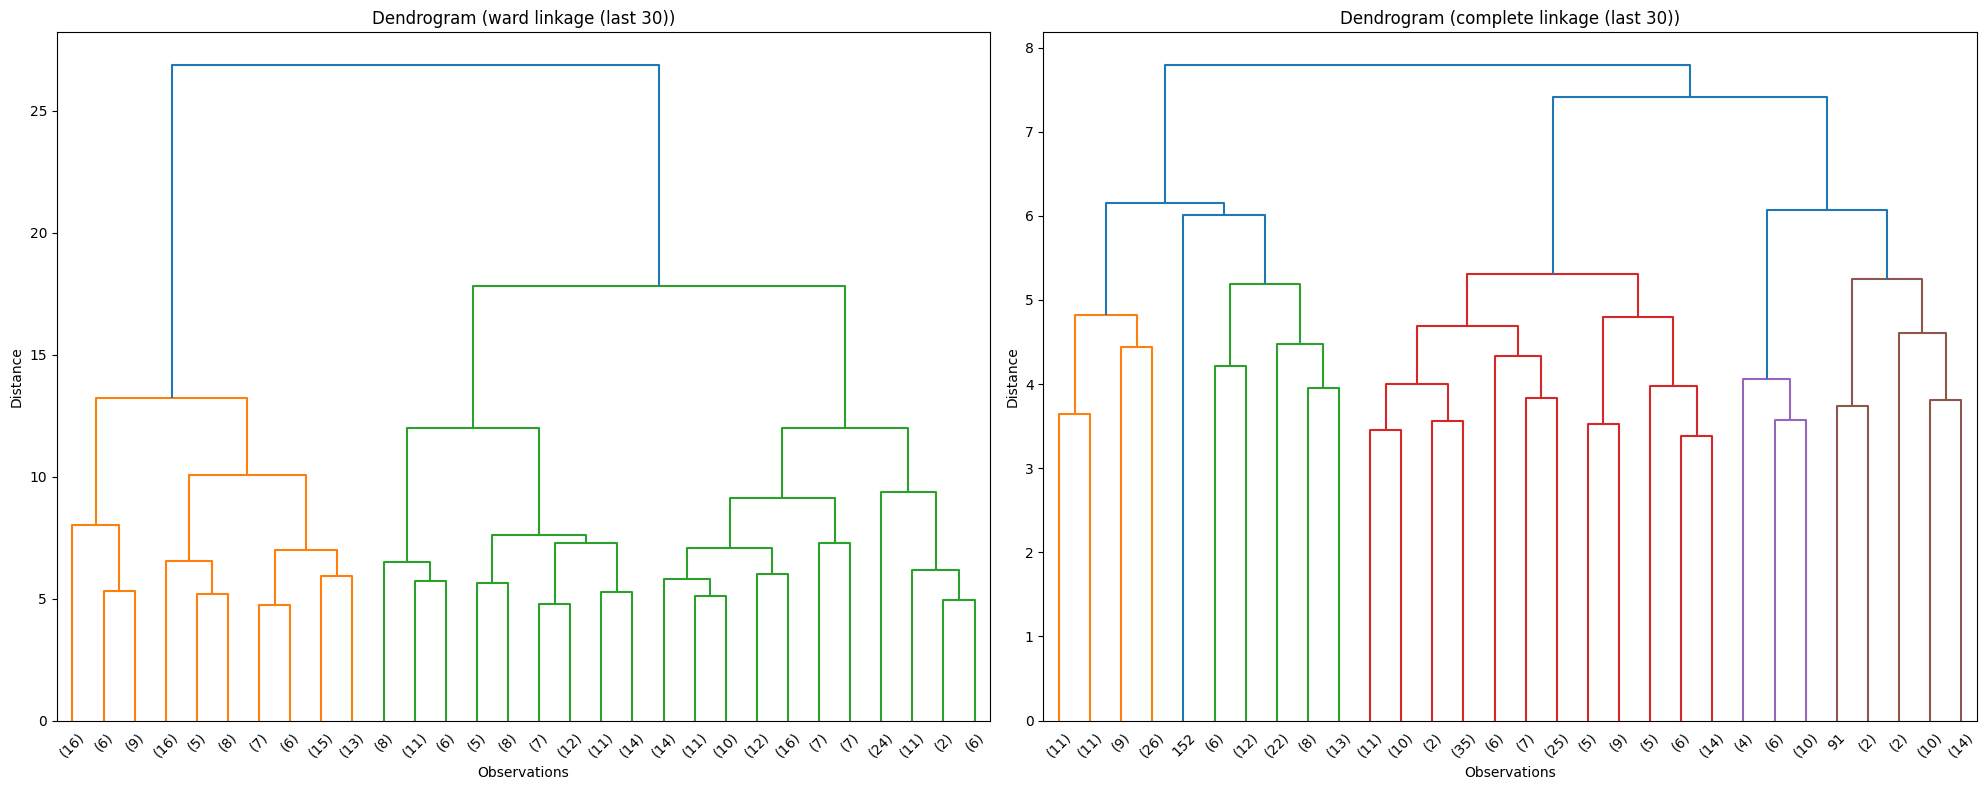

In [57]:
Z_ward = linkage(X_hier, method="ward")
Z_complete = linkage(X_hier, method="complete")

fig = plt.figure(figsize=(20, 8))

ward = fig.add_subplot(1, 2, 1)
# Last 30
dendrogram(Z_ward, truncate_mode="lastp", p=30)
ward.set_xlabel("Observations")
ward.set_ylabel("Distance")
ward.set_title("Dendrogram (ward linkage (last 30))")

complete = fig.add_subplot(1, 2, 2)
# Last 30
dendrogram(Z_complete, truncate_mode="lastp", p=30)
complete.set_xlabel("Observations")
complete.set_ylabel("Distance")
complete.set_title("Dendrogram (complete linkage (last 30))")

plt.tight_layout()
plt.savefig("figures/task5_dendograms_threshold.png", dpi=150, bbox_inches="tight")
plt.show()

- **Choose a cut point on the dendrogram and justify your choice.**

In the dendrogram obtained using Ward's linkage method, a cutoff point can be chosen at a distance of approximately 19. At this level, a notable increase in linkage distance is observed between successive merges, indicating that clusters below this height are more compact, while merges above this level combine more heterogeneous groups. Cutting the dendrogram at this height yields two main clusters, representing the most significant partitioning of the data.

In contrast, the dendrogram obtained using complete linkage shows a less clear separation between the groups. While a cutoff point around distance 7 could produce three clusters, the increase in linkage distance is more gradual, and the separation between the groups is less pronounced.

Therefore, the solution obtained using Ward's method provides a clearer and more interpretable cluster structure for this dataset. For this reason, the dendrogram obtained with Ward's method was chosen, resulting in a final solution of two clusters.

In [58]:
clustering_data_enc_hier = X_hier.copy()

clusters = fcluster(Z_ward, t=2, criterion="maxclust")
clustering_data_enc_hier["cluster_ward"] = clusters
clusters = fcluster(Z_complete, t=2, criterion="maxclust")
clustering_data_enc_hier["cluster_complete"] = clusters
clustering_data_enc_hier.head()

,ca,oldpeak,thalach,age,chol,cp_2.0,cp_3.0,cp_4.0,thal_3.0,thal_7.0,cluster_ward,cluster_complete
0,0.0,1.192005,0.017197,0.948726,-0.179214,0.0,0.0,0.0,0.0,0.0,1,1
1,3.0,0.661637,-1.821905,1.392002,0.830366,0.0,0.0,1.0,1.0,0.0,1,1
2,2.0,1.358226,-0.902354,1.392002,-0.264475,0.0,0.0,1.0,0.0,1.0,1,1
3,0.0,1.784504,1.637359,-1.932564,0.167589,0.0,1.0,0.0,1.0,0.0,2,2
4,0.0,0.583653,0.980537,-1.489288,-0.833495,1.0,0.0,0.0,1.0,0.0,2,2


In [59]:
clustering_data_enc_hier.cluster_complete.value_counts()

cluster_complete
2    184
1    119
Name: count, dtype: int64

In [60]:
clustering_data_enc_hier.cluster_ward.value_counts()

cluster_ward
2    202
1    101
Name: count, dtype: int64

In the complete linkage method, the clusters show less imbalance, with 184 and 119 observations, indicating a moderate difference in cluster size. In contrast, with Ward's linkage method, the clusters are more unbalanced (202 and 101 observations, respectively).

However, although the clusters obtained using complete linkage are slightly more balanced in size, the dendrogram does not show a clear separation between the clusters. Conversely, Ward's method shows a more pronounced increase in linkage distance before the final merging, suggesting a more defined and interpretable cluster structure.

- **Visualise the cluster assignments by projecting the data into PCA space (2D). Report and interpret the cluster centres directly in the original feature space, which features are highest or lowest for each group?.**

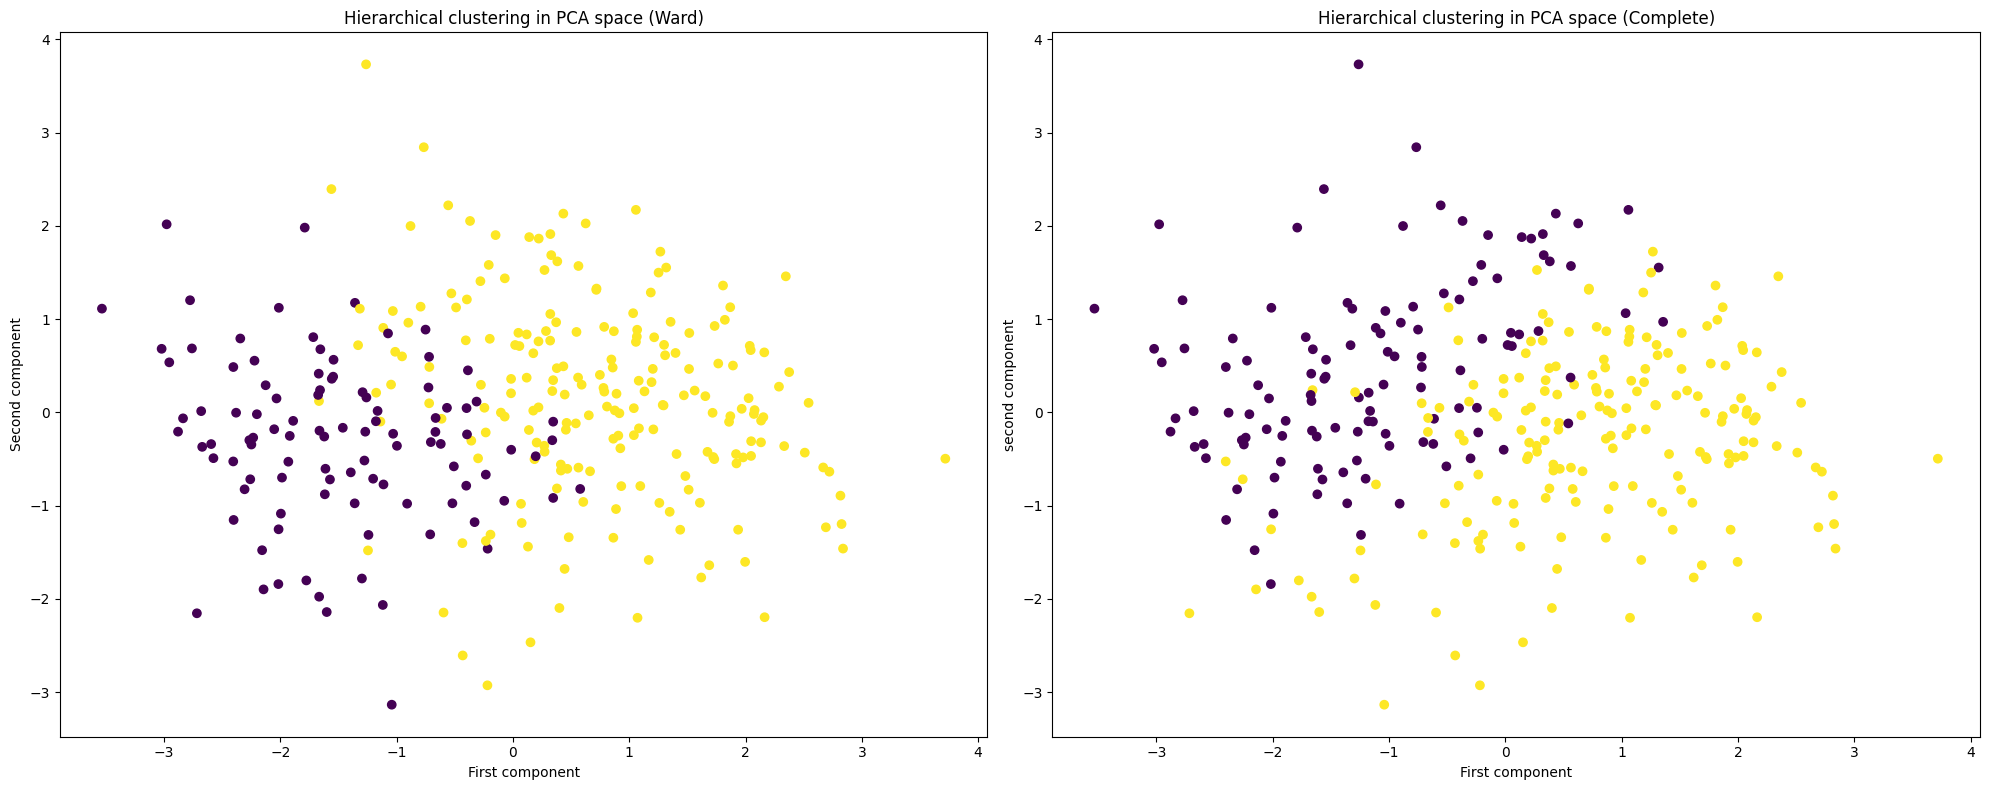

In [61]:
# Plot PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_hier)

fig = plt.figure(figsize=(20, 8))

ward = fig.add_subplot(1, 2, 1)
ward.scatter(X_pca[:, 0], X_pca[:, 1], c=clustering_data_enc_hier["cluster_ward"])
ward.set_xlabel("First component")
ward.set_ylabel("Second component")
ward.set_title("Hierarchical clustering in PCA space (Ward)")


complete = fig.add_subplot(1, 2, 2)
complete.scatter(X_pca[:, 0], X_pca[:, 1], c=clustering_data_enc_hier["cluster_complete"])
complete.set_xlabel("First component")
complete.set_ylabel("second component")
complete.set_title("Hierarchical clustering in PCA space (Complete)")

plt.tight_layout()
plt.savefig("figures/task5_hierarchical_clusters.png", dpi=150, bbox_inches="tight")
plt.show()

The first graph corresponds to Ward's linkage method. In this case, the two clusters appear clearly separated in the PCA projection, indicating that the observations within each cluster are relatively compact and well-differentiated. In contrast, the second graph represents the complete linkage method, where the points appear somewhat more mixed. This suggests that the separation between clusters is less pronounced with complete linkage. 
In conclusion, the PCA visualization confirms that Ward's method provides a clearer cluster structure.

In [62]:
mean_clusters_complete = X_hier.groupby(
    clustering_data_enc_hier["cluster_complete"]
).mean()
mean_clusters_complete.head()

,ca,oldpeak,thalach,age,chol,cp_2.0,cp_3.0,cp_4.0,thal_3.0,thal_7.0
cluster_complete,,,,,,,,,,
1,1.142857,0.496945,-0.389775,0.738264,0.579970,0.084034,0.218487,0.588235,0.428571,0.504202
2,0.353261,-0.321394,0.252083,-0.477464,-0.375089,0.217391,0.326087,0.402174,0.635870,0.309783


In the complete linkage method, the first group represents older patients who exhibit higher values in several cardiovascular risk-related variables, such as cholesterol (chol), ST-segment depression (oldpeak), and major vessels (ca). Conversely, this group shows lower values for maximum heart rate (thalach)

On the other hand, cluster 2 includes younger patients with lower values in these risk variables and a higher maximum heart rate. Overall, variables such as age, chol, oldpeak, ca, and thalach appear to be the main factors differentiating the two clusters

In [63]:
mean_clusters_ward = X_hier.groupby(
    clustering_data_enc_hier["cluster_ward"]
).mean()
mean_clusters_ward.head()

,ca,oldpeak,thalach,age,chol,cp_2.0,cp_3.0,cp_4.0,thal_3.0,thal_7.0
cluster_ward,,,,,,,,,,
1,1.158416,0.845449,-0.930534,0.528493,0.068303,0.019802,0.089109,0.811881,0.297030,0.574257
2,0.415842,-0.422725,0.465267,-0.264246,-0.034152,0.237624,0.381188,0.306931,0.683168,0.292079


In Ward's linkage method, cluster 1 is characterized by higher values for age, oldpeak, and calcium, but lower values for heart rate and thalach. This group indicates older patients with a higher cardiovascular risk.

Conversely, cluster 2 shows lower values for age, oldpeak, and calcium, but higher values for maximum heart rate, indicating individuals with a lower cardiovascular risk. Overall, variables such as age, oldpeak, cal, and thalach appear to be the main factors that distinguish the two clusters.

- **Discuss how hierarchical clustering differs structurally from the previous two methods.**

In the K-Means clustering method, the number of clusters (K) is first defined and the centroids are initialized. Then, each point in the dataset is assigned to the nearest center. Next, the centers of each cluster are recalculated as the mean of the points belonging to it. This process is repeated until the centers stop changing.

In the Gaussian Mixture Model (GMM) clustering method, the number of components (clusters) is first defined and the parameters of each Gaussian distribution are initialized (mean, covariance and weight). Then, for each data point, the probability of belonging to each cluster is calculated. Next, the parameters of the Gaussian distributions are updated using these probabilities. This process is repeated iteratively using the Expectation Maximization algorithm until the parameters stop changing. Unlike K-Means, where each observation belongs to only one cluster, GMM assigns probabilities of belonging to each cluster.

These two methods require specifying the number of clusters beforehand. In contrast, algorithmic hierarchical clustering progressively merges observations according to a linkage criterion, generating a dendrogram that shows the relationships between the data. From this dendrogram, the number of clusters can be chosen by making a cut at a certain level. Therefore, while K-means and GMM produce a single clustering solution, hierarchical clustering allows exploring the data structure at different levels of grouping.

<a id='section36'></a>
### **Task 6 - Evaluation Against Ground Truth**

Now reveal the target label and evaluate your clustering results:

- **Compute the Adjusted Rand Index (ARI) for each method.**

In [64]:
# Criteria: Computed correctly for all three methods. Results tabulated.

# Convert target to binary
evaluation_data = df["target"]
y_true = (evaluation_data > 0).astype(int)

In [65]:
# ARI for KMeans
ari_kmeans = adjusted_rand_score(y_true, km_cluster_labels)
print("KMeans ARI:", ari_kmeans)

KMeans ARI: 0.20405577357860308


In [66]:
# ARI for GMM
ari_gmm = adjusted_rand_score(y_true, best_labels)
print("GMM ARI:", ari_gmm)

GMM ARI: 0.12855625099744822


- **Plot a confusion-style matrix showing how clusters map to the binary target (disease / no disease).**

In [67]:
# Criteria: Matrix plotted. Best method identified and explanation is data-driven.



- **Which method best recovered the true patient groups? Discuss why, referencing the nature of the data and the assumptions of each algorithm.**